Comparison plots of stellar masses estimates in our sample (see *oursample.ipynb*).

The code was written by Mária Pálfi (marika97@student.elte.hu).

#### Preparations

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

import scipy.stats as stats
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from pyrolite.plot.density import density

import seaborn as sns
sns.set_style('white') # set figure style
import mpl_scatter_density
from matplotlib import colormaps as cm
from matplotlib.lines import Line2D

In [2]:
# reading the file to pandas dataframe
check = pd.read_csv( '../check_sm.txt', delimiter = '\t', low_memory = False )
check.head()

,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,...,log_sm,d_log_sm,fluxscale,log_gama_sm,log_sm_lambdar,d_log_sm_lambdar,fluxscale_lambdar,log_gama_sm_lambdar,sm,log_gama_sm_magphys
0,260,12125210+0117588,J121252.11+011758.9,G,183.217087,1.299673,7.953,0.015,8.868,NaN,...,10.67840,0.104434,1.077330,10.740281,10.67200,0.108565,1.076980,10.733740,26270000000,10.419460
1,1025,14463127+0116286,J144631.24+011629.2,G,221.630325,1.274620,10.528,0.048,10.926,NaN,...,11.08790,0.110348,1.165130,11.183806,11.08410,0.112150,1.255260,11.212366,126100000000,11.100715
2,1656,14441893+0002312,J144418.90+000230.8,G,221.078888,0.042021,11.229,0.071,11.679,NaN,...,10.69100,0.109208,1.254340,10.818947,10.68640,0.119500,0.984636,10.709208,33090000000,10.519697
3,1899,12024266+0157083,J120242.71+015707.2,G,180.677765,1.952326,11.402,0.075,12.060,NaN,...,10.44000,0.113381,0.875903,10.411988,10.41900,0.107483,1.071390,10.478480,28080000000,10.448397
4,2791,08360330+0119469,J083603.32+011947.2,G,129.013763,1.329719,12.066,0.081,12.225,0.023,...,9.83516,0.115833,1.112100,9.910836,9.84532,0.109942,1.118270,9.923399,3542000000,9.549249


#### Fraction plots

In [3]:
def fraction_plot( sample, gama, name, fname, xname = '$M_{MagPhys}$', fsize = (20, 12), fs = 40, fst = 35, zarr = check.z, 
                   GAMA = False, xmin = 8, xmax = 13, ymin = None, ymax = None, size = 3 ):
    fig = plt.figure( figsize = (fsize), dpi = 100 )
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    plt.xlabel( '$\log_{10}($' + xname + ' [M$_{\odot}$])', fontsize = fs )
    plt.ylabel( name, fontsize = fs )
    plt.xticks( fontsize = fst )
    plt.yticks( fontsize = fst )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)
    plt.rcParams["font.size"] = 30
    plt.xlim(xmin, xmax)
    if ymin != None:
        plt.ylim(ymin, ymax)
    plt.hlines(0, xmin, xmax, color = 'k', zorder = 5 )
    z = zarr
    newcmp = cm.get_cmap('turbo')
    if GAMA == True:
        col = plt.scatter( gama, sample - gama, s = size, 
                           c=z, vmin = np.nanmin(z), vmax = np.nanmax(z),  zorder = 10, cmap=newcmp )
    else:
        col = plt.scatter( gama, np.log10(sample) - gama, s = size,
                           c=z, vmin = np.nanmin(z), vmax = np.nanmax(z),  zorder = 10,  cmap=newcmp )
    cbar = plt.colorbar(col)
    cbar.ax.set_ylabel('Redshift', fontsize = fs)
    cbar.ax.tick_params(labelsize=fs-5)
    plt.grid()
    plt.savefig( fname, format = 'pdf' );

Whole fraction plots with $M_\ast$ from GAMA *StellarMasses* table:

In [4]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm, 'Kettlety', '../new_plots/fraction_SM_Kettlety_whole.pdf', 
              xname = '$M_{StellarMasses}$' ) 
plt.close()
fraction_plot( check.SMass_Cluver, check.log_gama_sm, 'Cluver', '../new_plots/fraction_SM_Cluver_whole.pdf',
              xname = '$M_{StellarMasses}$' )
plt.close()
fraction_plot( check.SMass_Jarrett, check.log_gama_sm, 'Jarrett', '../new_plots/fraction_SM_Jarrett_whole.pdf', 
              xname = '$M_{StellarMasses}$' )
plt.close()
fraction_plot( check.SMass_Cappellari, check.log_gama_sm, 'Cappellari', '../new_plots/fraction_SM_Cappellari_whole.pdf', 
              xname = '$M_{StellarMasses}$' )
plt.close()

Zooming in to fraction plots with $M_\ast$ from GAMA *StellarMasses* table:

In [5]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm, 'Kettlety', '../new_plots/fraction_SM_Kettlety.pdf', xname = '$M_{StellarMasses}$',
              ymin = -1, ymax = 1, xmin = 9, xmax = 12.5 ) 
plt.close()
fraction_plot( check.SMass_Cluver, check.log_gama_sm, 'Cluver', '../new_plots/fraction_SM_Cluver.pdf', xname = '$M_{StellarMasses}$',
             ymin = -1.5, ymax = 1, xmin = 9, xmax = 12.5 )
plt.close()
fraction_plot( check.SMass_Jarrett, check.log_gama_sm, 'Jarrett', '../new_plots/fraction_SM_Jarrett.pdf', xname = '$M_{StellarMasses}$',
              ymin = -1.5, ymax = 1, xmin = 9, xmax = 12.5 )
plt.close()
fraction_plot( check.SMass_Cappellari, check.log_gama_sm, 'Cappellari', '../new_plots/fraction_SM_Cappellari.pdf',
              xname = '$M_{StellarMasses}$', ymin = -0.5, ymax = 1.5, xmin = 9, xmax = 12.5 )
plt.close()

Whole fraction plots with $M_\ast$ from GAMA *StellarMassesLambdar* table:

In [6]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm_lambdar, '$M_{Kettlety}$', '../new_plots/fraction_SMLambdar_Kettlety_whole.pdf',
              xname = '$M_{StellarMassesLambdar}$' ) 
plt.close()
fraction_plot( check.SMass_Cluver, check.log_gama_sm_lambdar, '$M_{Cluver}$', '../new_plots/fraction_SMLambdar_Cluver_whole.pdf',
              xname = '$M_{StellarMassesLambdar}$' )
plt.close()
fraction_plot( check.SMass_Jarrett, check.log_gama_sm_lambdar, '$M_{Jarrett}$', '../new_plots/fraction_SMLambdar_Jarrett_whole.pdf',
              xname = '$M_{StellarMassesLambdar}$' )
plt.close()
fraction_plot( check.SMass_Cappellari, check.log_gama_sm_lambdar, '$M_{Cappellari}$',  '../new_plots/fraction_SMLambdar_Cappellari_whole.pdf', 
              xname = '$M_{StellarMassesLambdar}$' )
plt.close()

Zooming in to fraction plots with $M_\ast$ from GAMA *StellarMassesLambdar* table:

In [7]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm_lambdar, 'Kettlety', '../new_plots/fraction_SMLambdar_Kettlety.pdf',
              xname = '$M_{StellarMassesLambdar}$', ymin = -1, ymax = 1, xmin = 9, xmax = 12.5 ) 
plt.close()
fraction_plot( check.SMass_Cluver, check.log_gama_sm_lambdar, 'Cluver', '../new_plots/fraction_SMLambdar_Cluver.pdf', 
              xname = '$M_{StellarMassesLambdar}$', ymin = -1.5, ymax = 1, xmin = 9, xmax = 12.5 )
plt.close()
fraction_plot( check.SMass_Jarrett, check.log_gama_sm_lambdar, 'Jarrett', '../new_plots/fraction_SMLambdar_Jarrett.pdf', 
              xname = '$M_{StellarMassesLambdar}$', ymin = -1.5, ymax = 1, xmin = 9, xmax = 12.5 )
plt.close()
fraction_plot( check.SMass_Cappellari, check.log_gama_sm_lambdar, 'Cappellari', '../new_plots/fraction_SMLambdar_Cappellari.pdf',
              xname = '$M_{StellarMassesLambdar}$', ymin = -0.5, ymax = 1.5, xmin = 9, xmax = 12.5 )
plt.close()

Whole fraction plots with $M_\ast$ from GAMA *MagPhys* table:

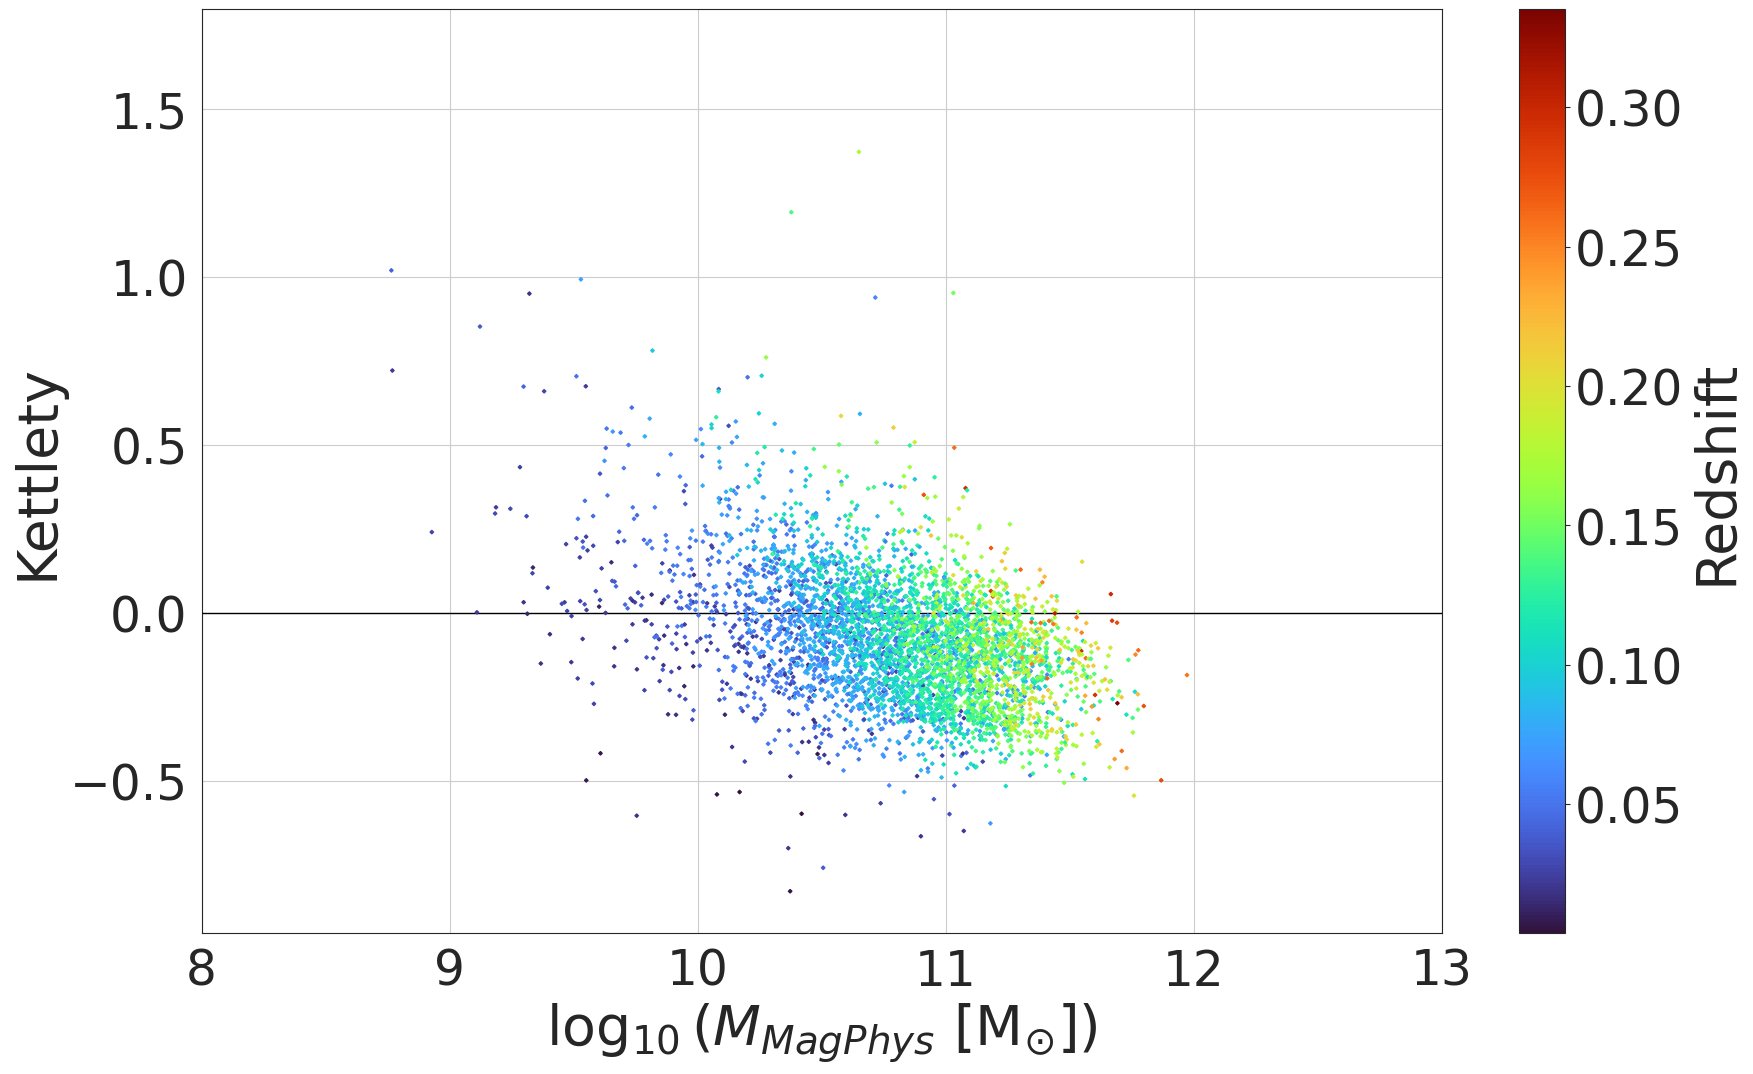

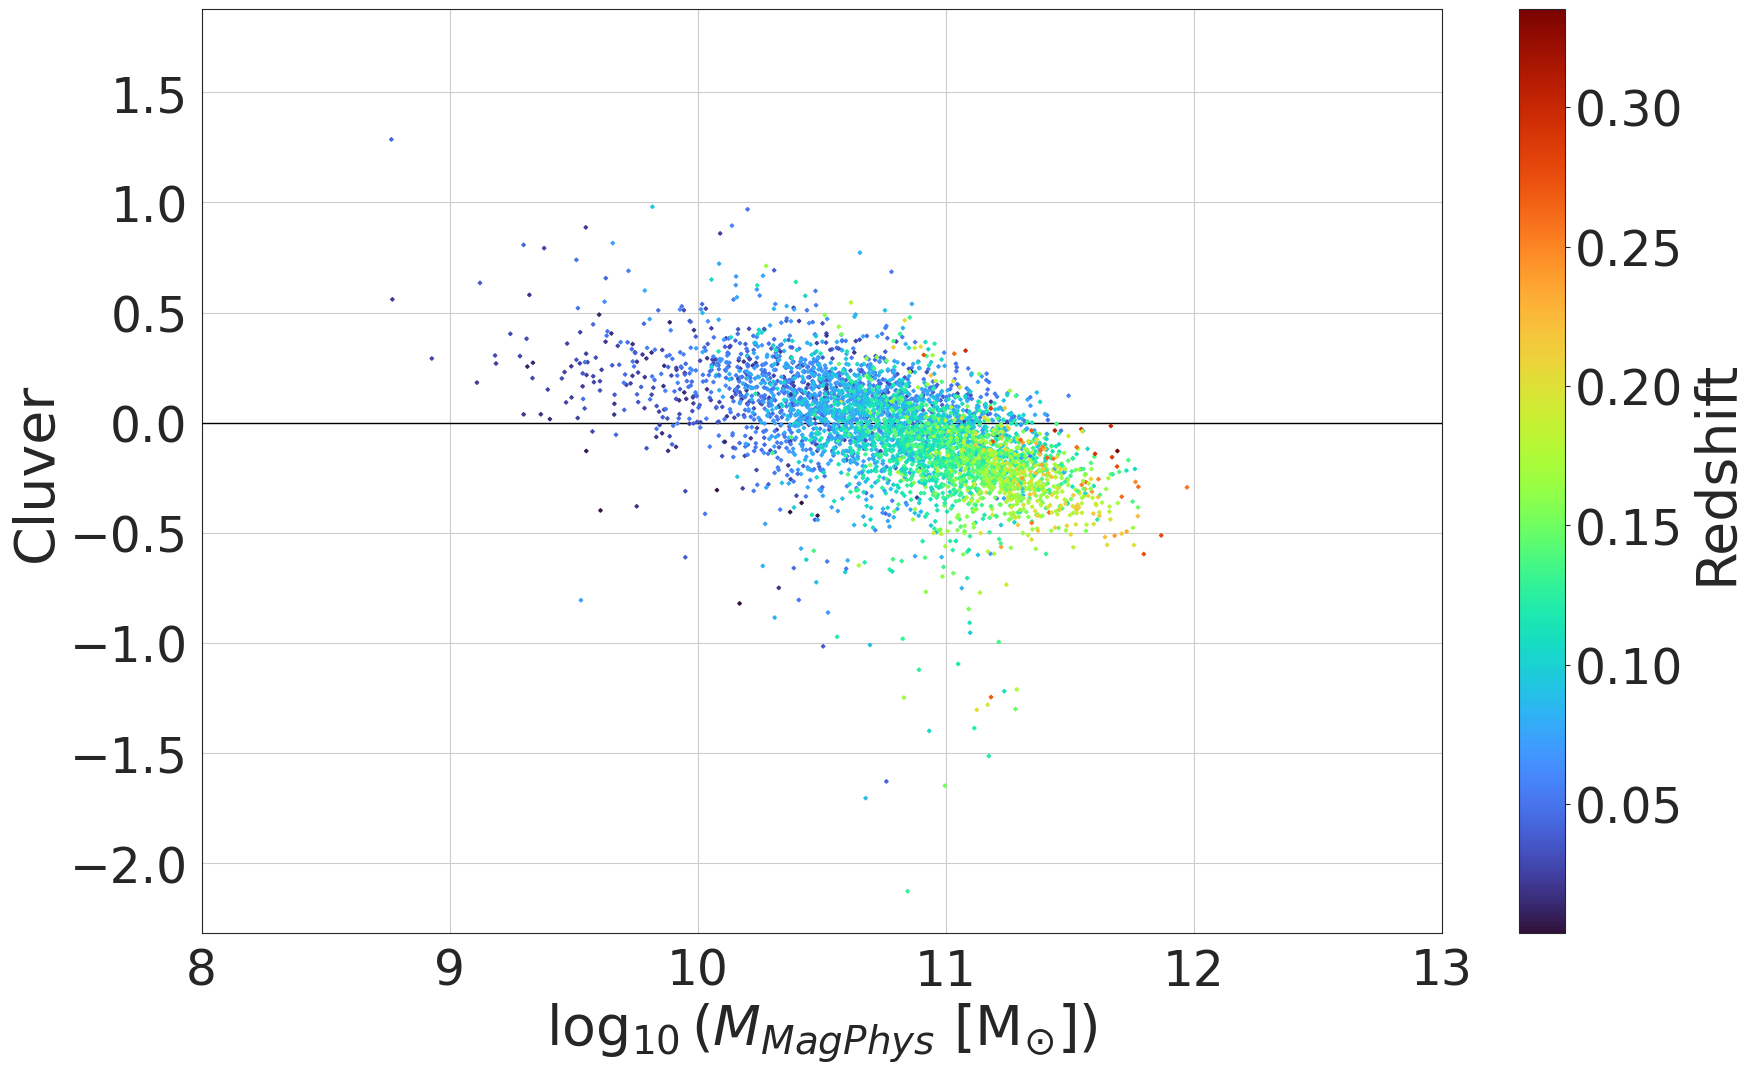

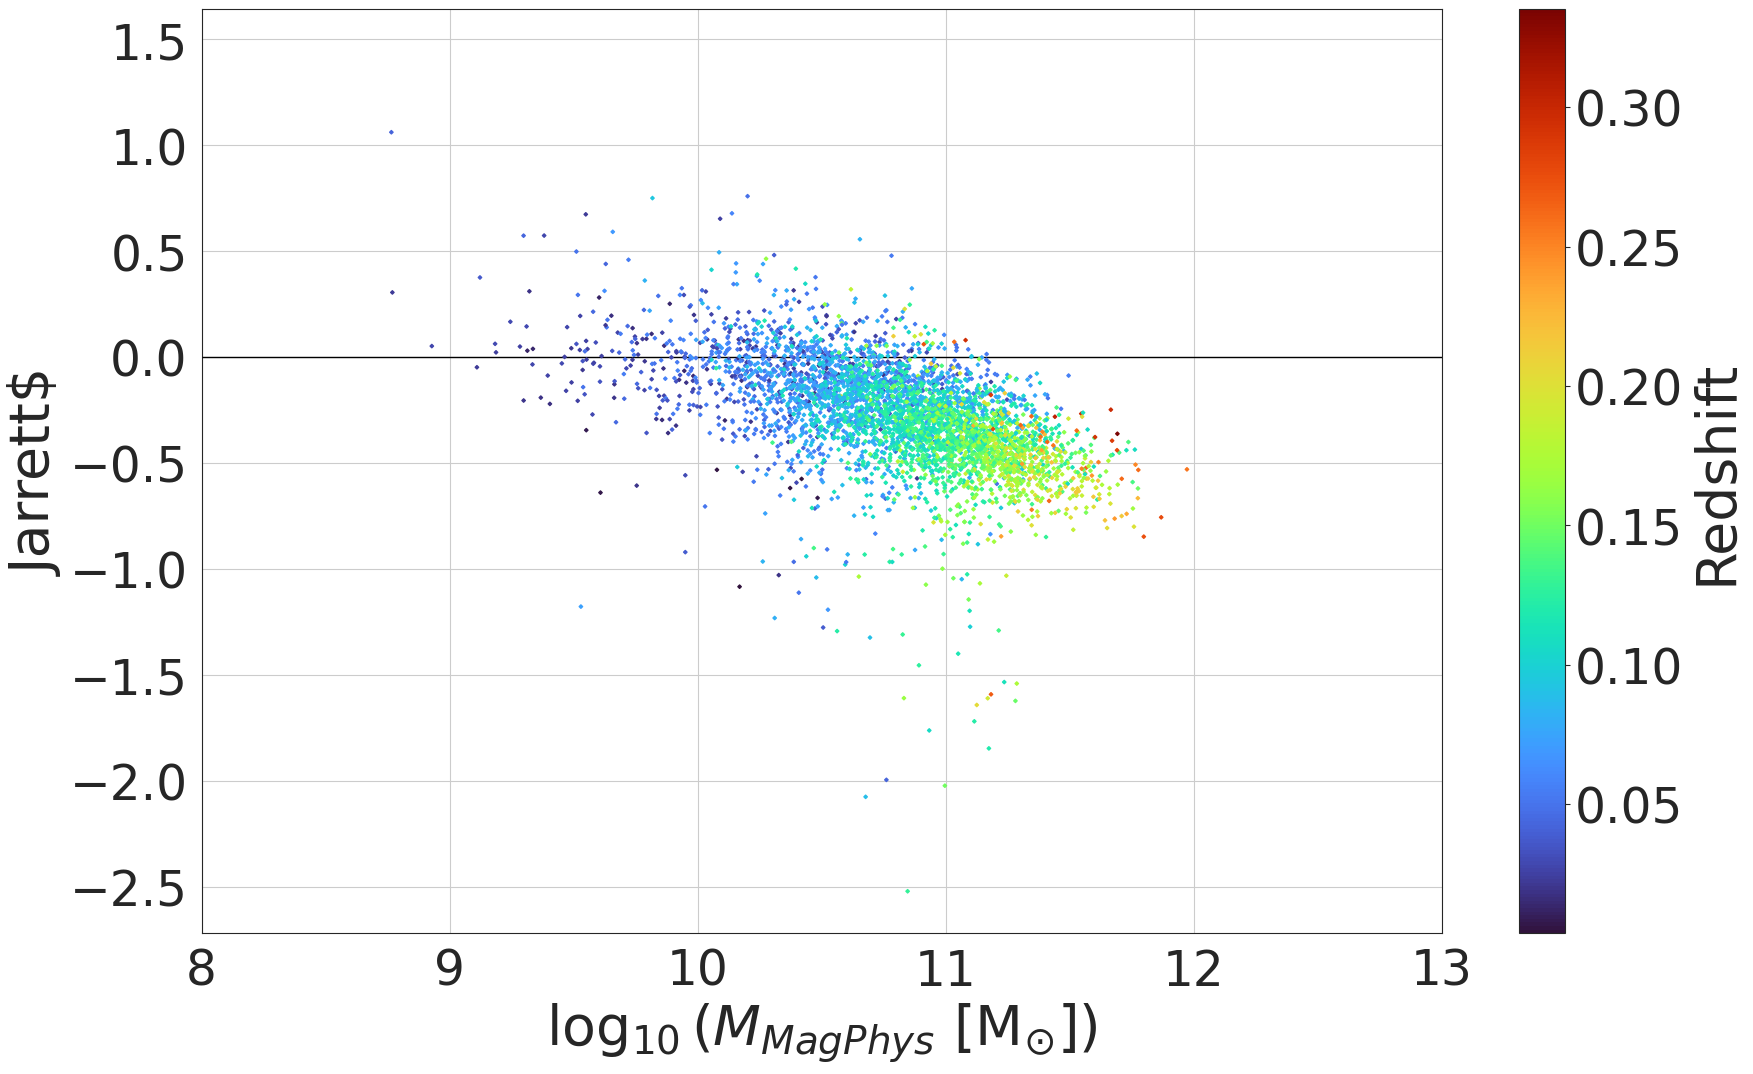

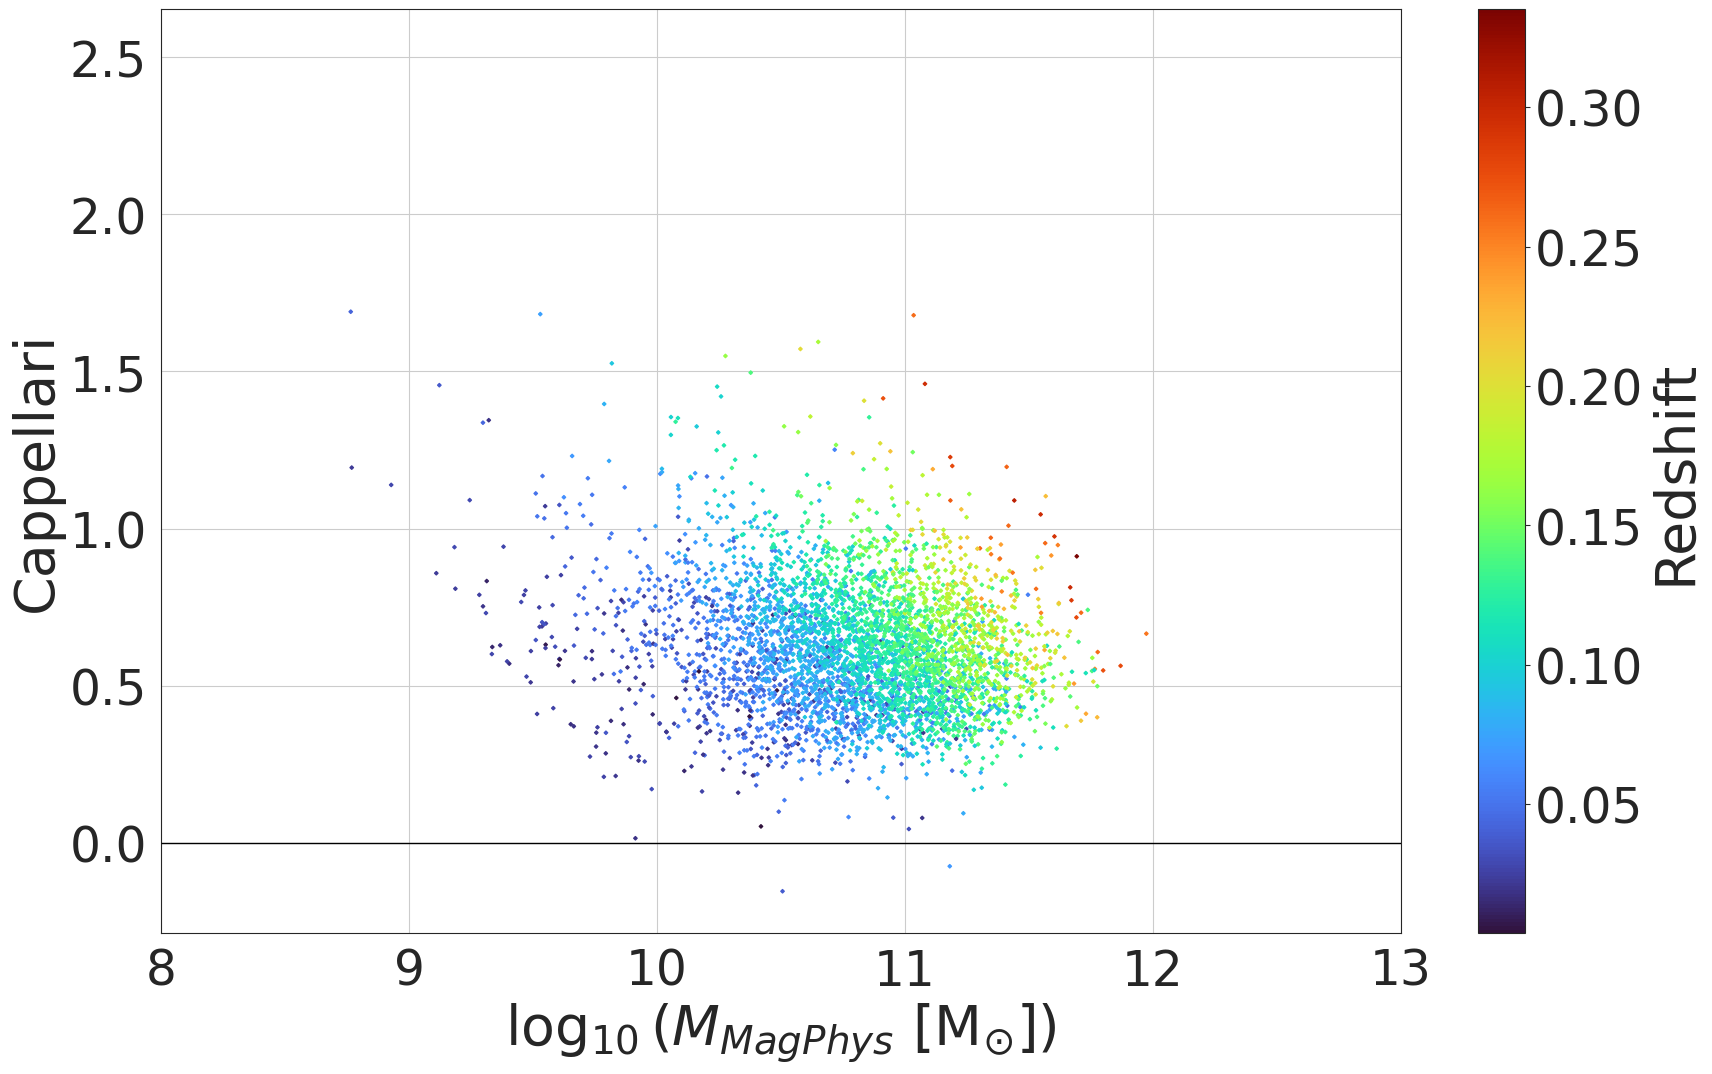

In [8]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm_magphys, 'Kettlety', '../new_plots/fraction_MagPhys_Kettlety_whole.pdf' ) 
fraction_plot( check.SMass_Cluver, check.log_gama_sm_magphys, 'Cluver', '../new_plots/fraction_MagPhys_Cluver_whole..pdf' )
fraction_plot( check.SMass_Jarrett, check.log_gama_sm_magphys, 'Jarrett$', '../new_plots/fraction_MagPhys_Jarrett_whole..pdf' )
fraction_plot( check.SMass_Cappellari, check.log_gama_sm_magphys, 'Cappellari', '../new_plots/fraction_MagPhys_Cappellari_whole..pdf' )

Zooming in to fraction plots with $M_\ast$ from GAMA *MagPhys* table:

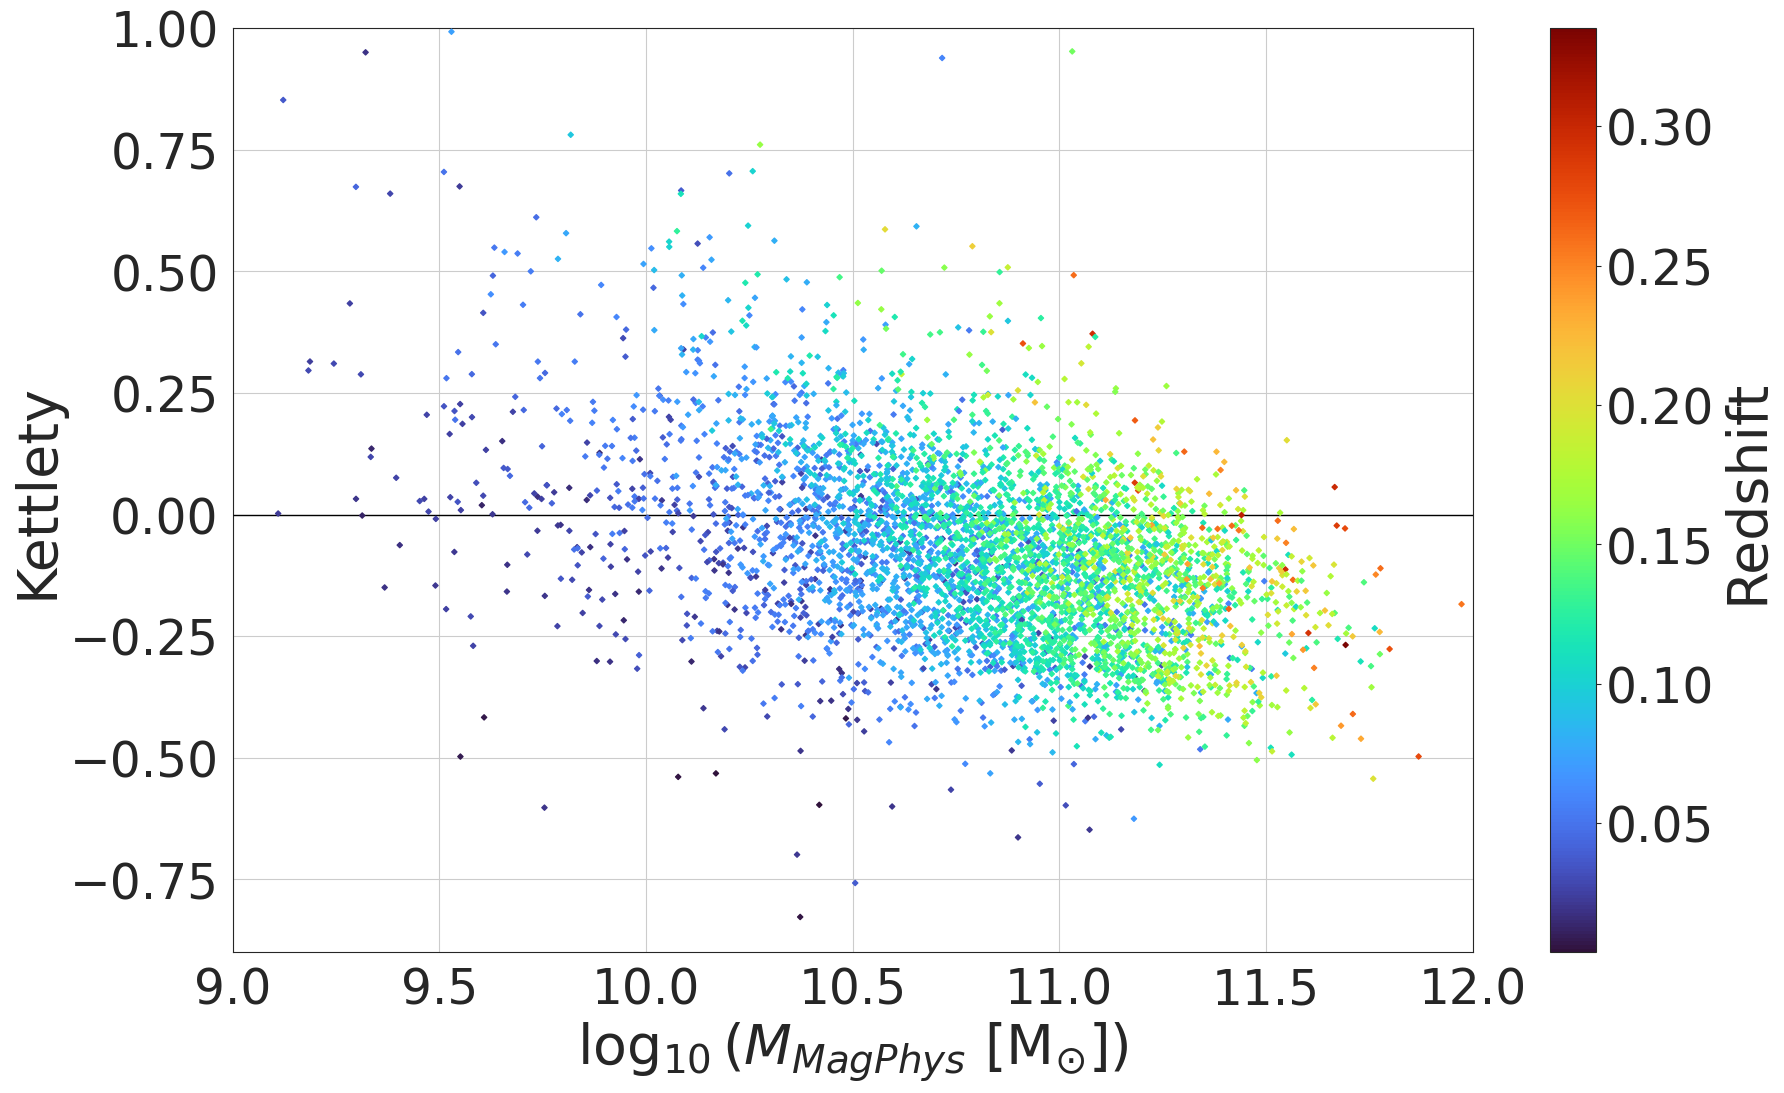

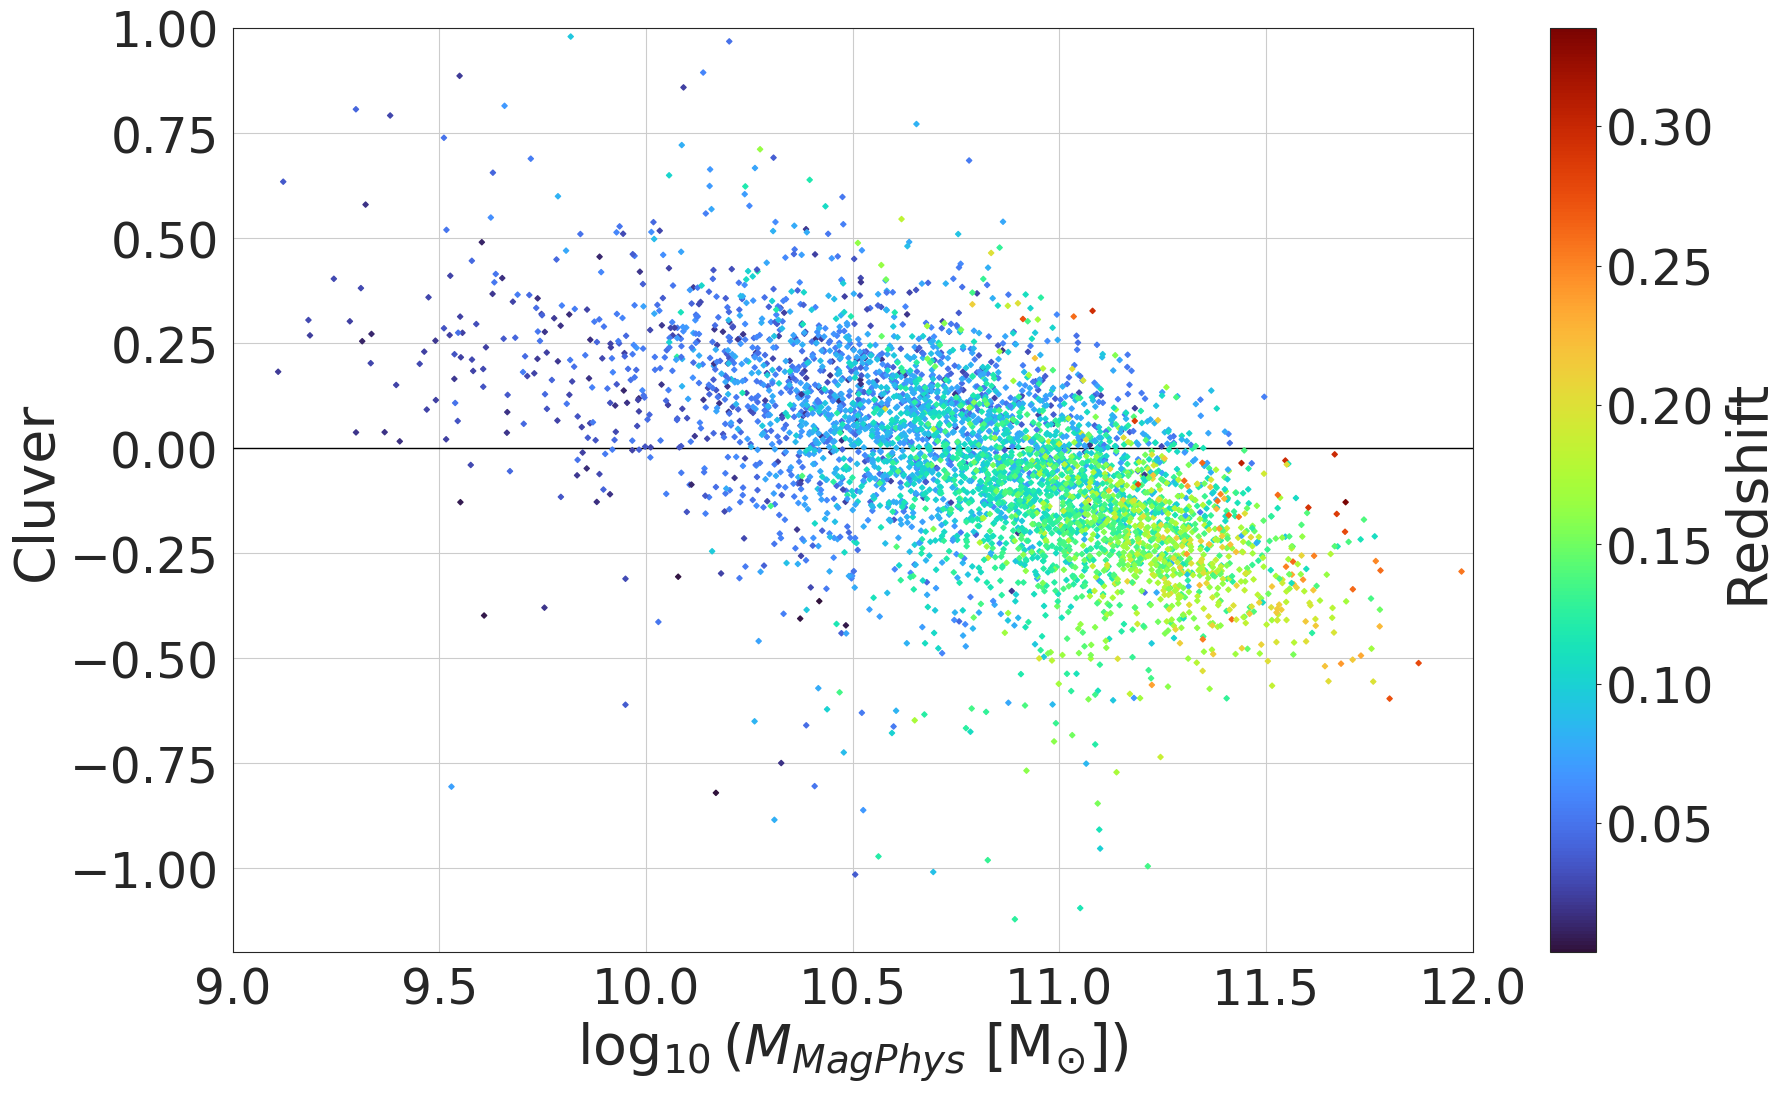

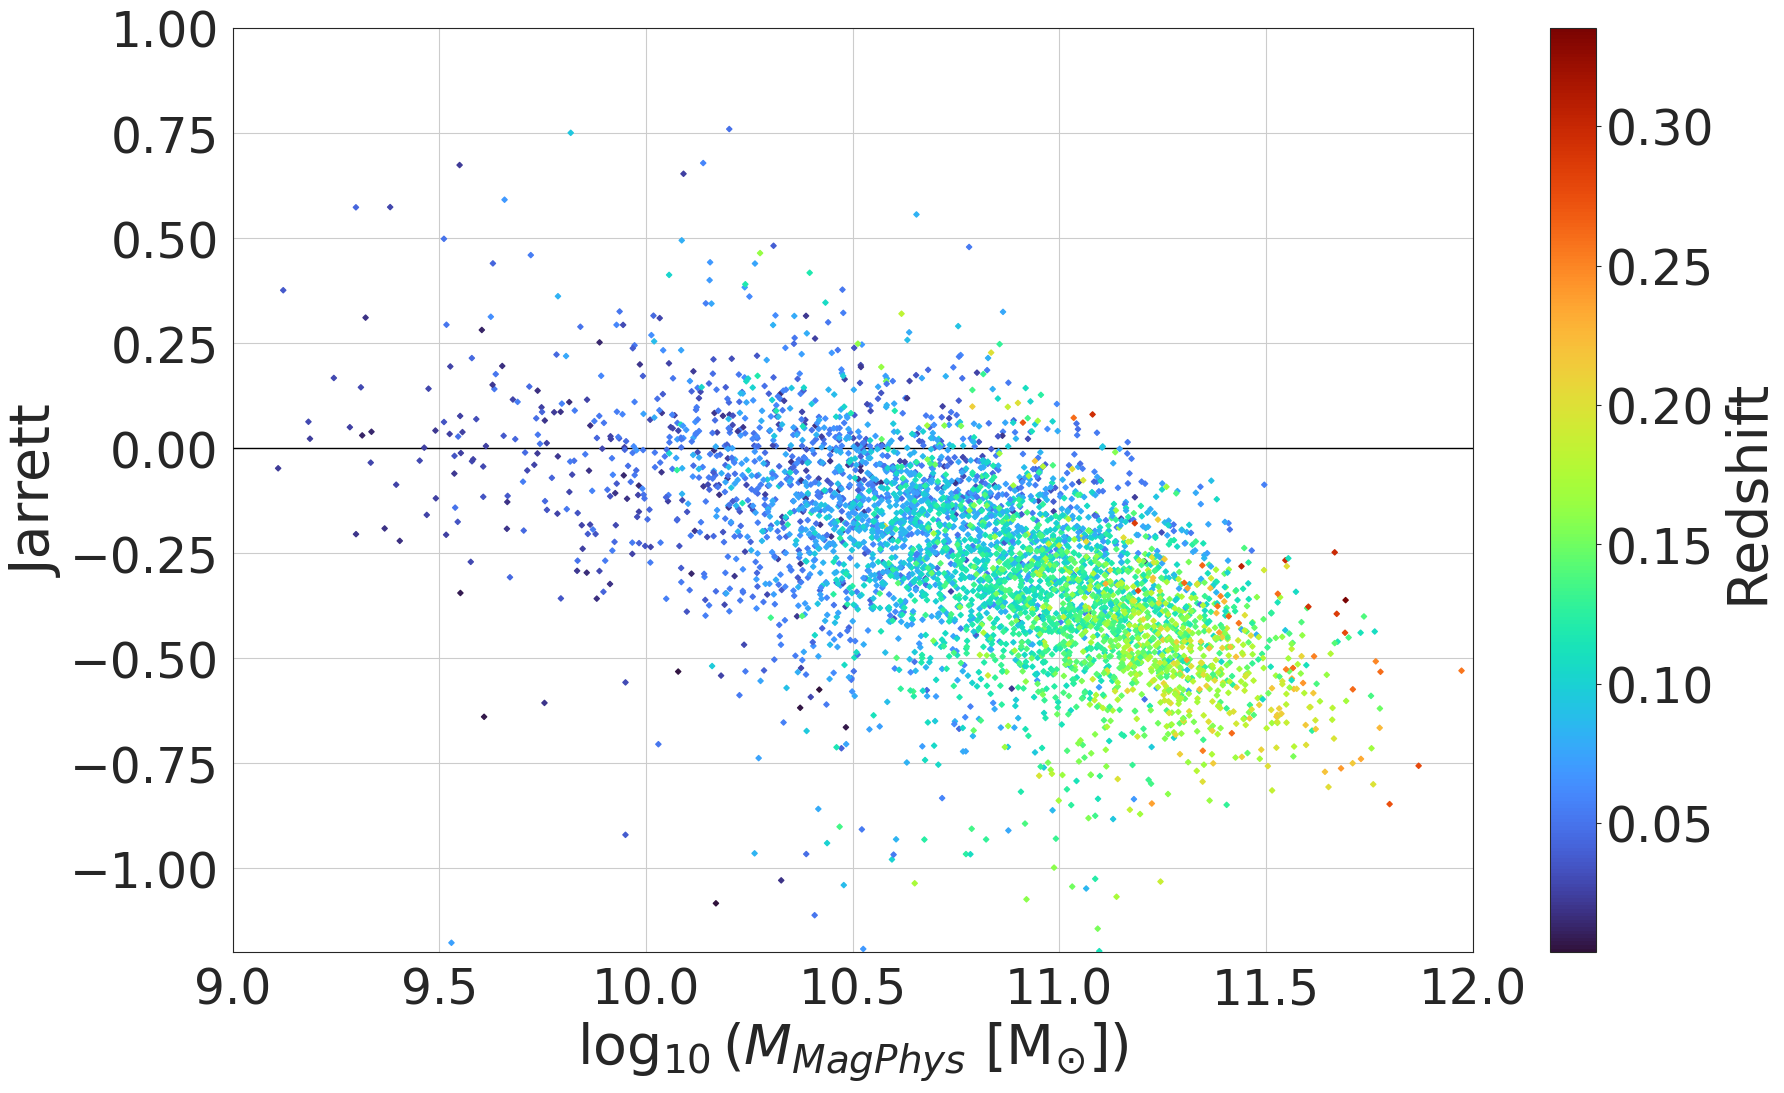

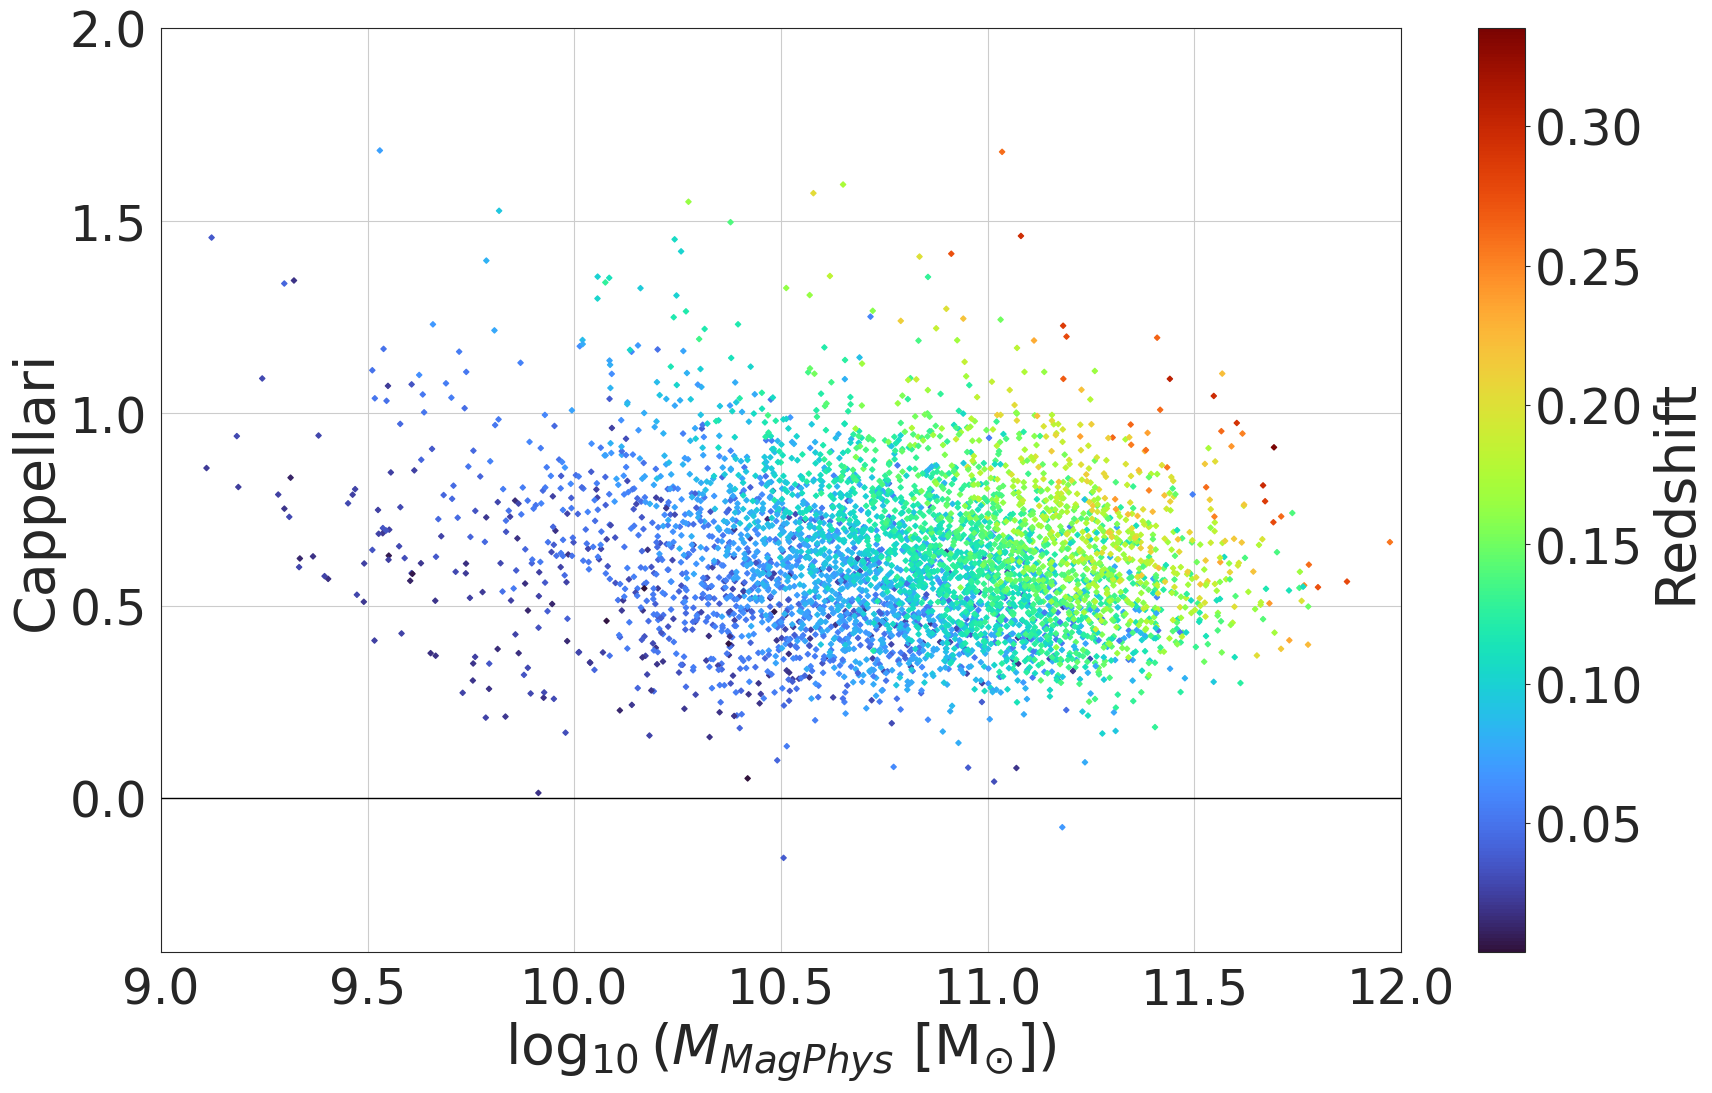

In [9]:
fraction_plot( check.SMass_Kettlety, check.log_gama_sm_magphys, 'Kettlety', '../new_plots/fraction_MagPhys_Kettlety.pdf',
               xmin = 9, xmax = 12, ymin = -0.9, ymax = 1, size = 7) 
fraction_plot( check.SMass_Cluver, check.log_gama_sm_magphys, 'Cluver', '../new_plots/fraction_MagPhys_Cluver.pdf', 
               xmin = 9, xmax = 12, ymin = -1.2, ymax = 1, size = 7 )
fraction_plot( check.SMass_Jarrett, check.log_gama_sm_magphys, 'Jarrett', '../new_plots/fraction_MagPhys_Jarrett.pdf', 
               xmin = 9, xmax = 12, ymin = -1.2, ymax = 1, size = 7 )
fraction_plot( check.SMass_Cappellari, check.log_gama_sm_magphys, 'Cappellari', '../new_plots/fraction_MagPhys_Cappellari.pdf', 
               xmin = 9, xmax = 12, ymin = -0.4, ymax = 2, size = 7 )

Fraction plots for galaxies with $z < 0.15$:

In [10]:
check_lowz = copy.deepcopy( check[check.z < 0.15] )

In [11]:
print( f"""The number of galaxies with z < 0.15 is {len(check_lowz)}, 
which is {np.round(100*len(check_lowz)/len(check), decimals=2)}% of the sample.""")

The number of galaxies with z < 0.15 is 3674, 
which is 84.62% of the sample.


With $M_\ast$ from GAMA *StellarMasses* table:

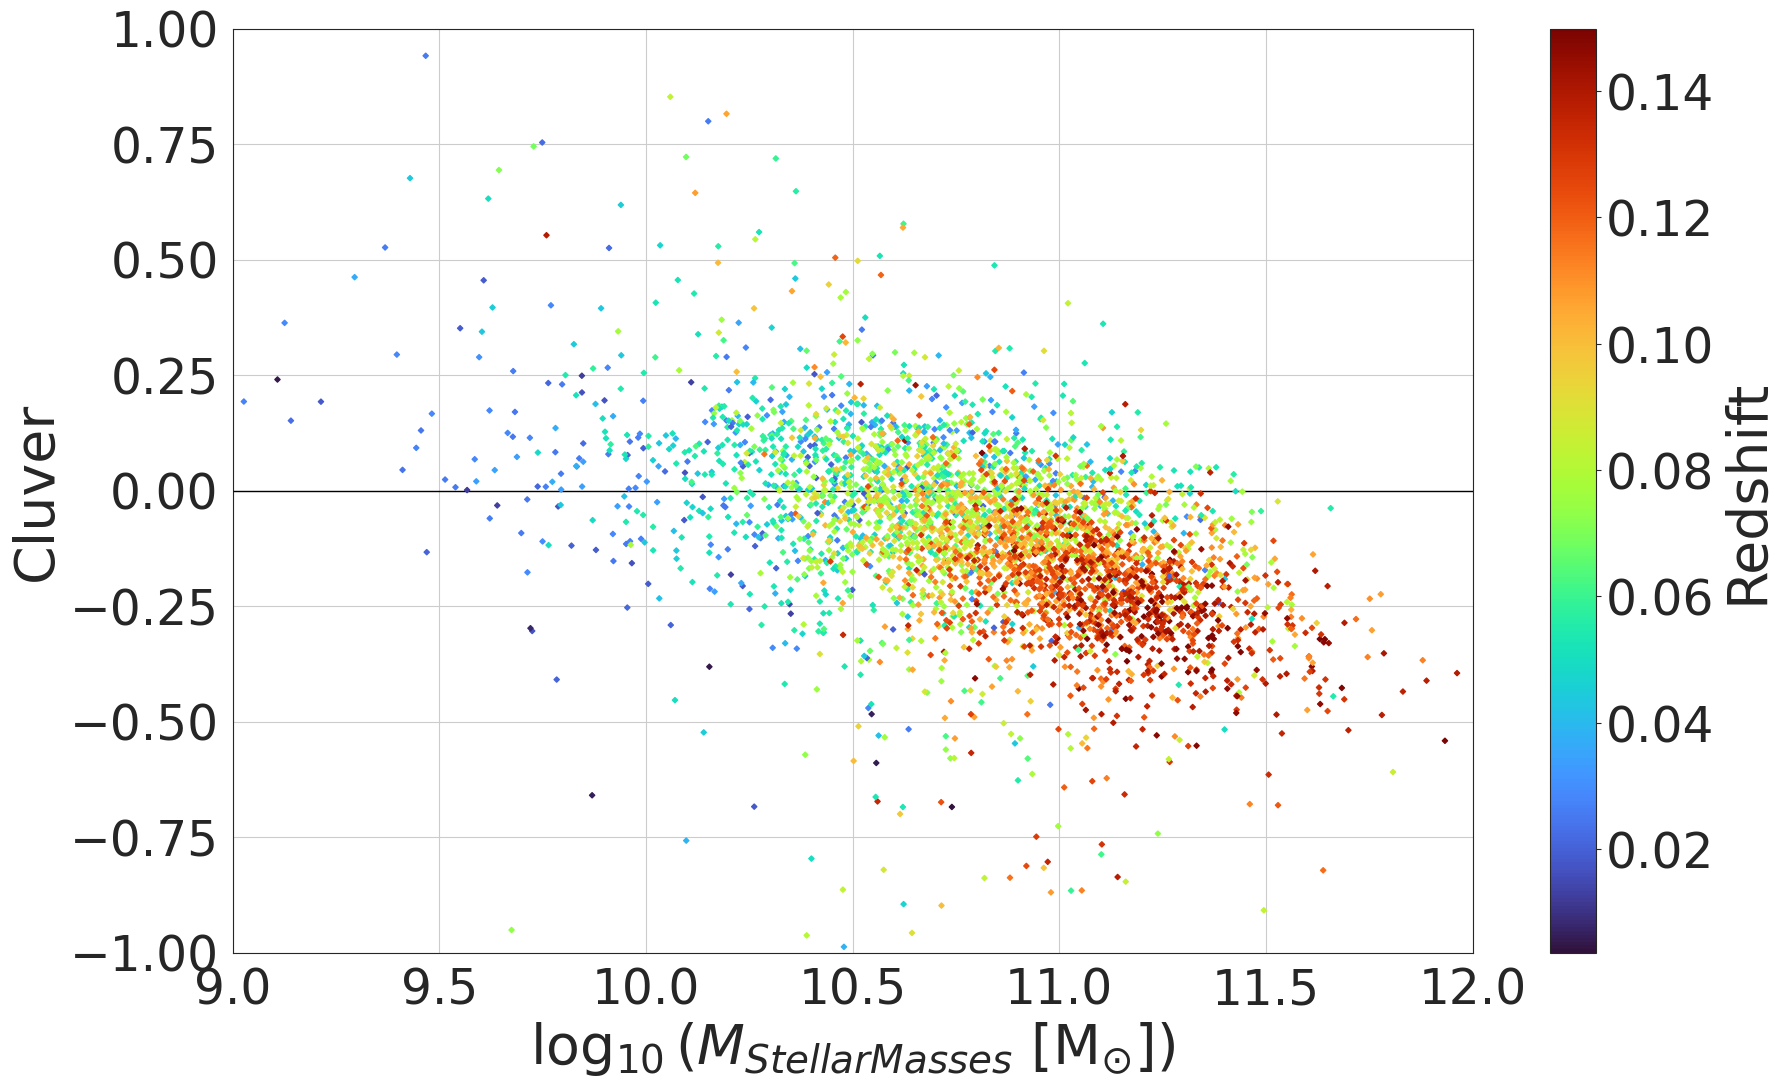

In [12]:
fraction_plot( check_lowz.SMass_Kettlety, check_lowz.log_gama_sm, 'Kettlety', '../new_plots_15/fraction_SM_Kettlety.pdf',
              xname = '$M_{StellarMasses}$', zarr=check_lowz.z ) 
plt.close()
fraction_plot( check_lowz.SMass_Cluver, check_lowz.log_gama_sm, 'Cluver', '../new_plots_15/fraction_SM_Cluver.pdf',
              xname = '$M_{StellarMasses}$', zarr=check_lowz.z, xmin = 9, xmax = 12, ymin = -1, ymax = 1, size = 7)
fraction_plot( check_lowz.SMass_Jarrett, check_lowz.log_gama_sm, 'Jarrett', '../new_plots_15/fraction_SM_Jarrett.pdf',
              xname = '$M_{StellarMasses}$', zarr=check_lowz.z)
plt.close()
fraction_plot( check_lowz.SMass_Cappellari, check_lowz.log_gama_sm, 'Cappellari', '../new_plots_15/fraction_SM_Cappellari.pdf',
              xname = '$M_{StellarMasses}$', zarr=check_lowz.z)
plt.close()

With $M_\ast$ from GAMA *StellarMassesLambdar* table:

In [13]:
fraction_plot( check_lowz.SMass_Kettlety, check_lowz.log_gama_sm_lambdar, 'Kettlety', '../new_plots_15/fraction_SMLambdar_Kettlety.pdf',
              xname = '$M_{StellarMassesLambdar}$', zarr=check_lowz.z) 
plt.close()
fraction_plot( check_lowz.SMass_Cluver, check_lowz.log_gama_sm_lambdar, 'Cluver', '../new_plots_15/fraction_SMLambdar_Cluver.pdf',
               xname = '$M_{StellarMassesLambdar}$', zarr=check_lowz.z)
plt.close()
fraction_plot( check_lowz.SMass_Jarrett, check_lowz.log_gama_sm_lambdar, 'Jarrett', '../new_plots_15/fraction_SMLambdar_Jarrett.pdf',
               xname = '$M_{StellarMassesLambdar}$', zarr=check_lowz.z)
plt.close()
fraction_plot( check_lowz.SMass_Cappellari, check_lowz.log_gama_sm_lambdar, 'Cappellari', '../new_plots_15/fraction_SMLambdar_Cappellari.pdf',
               xname = '$M_{StellarMassesLambdar}$', zarr=check_lowz.z)
plt.close()

With $M_\ast$ from GAMA *MagPhys* table:

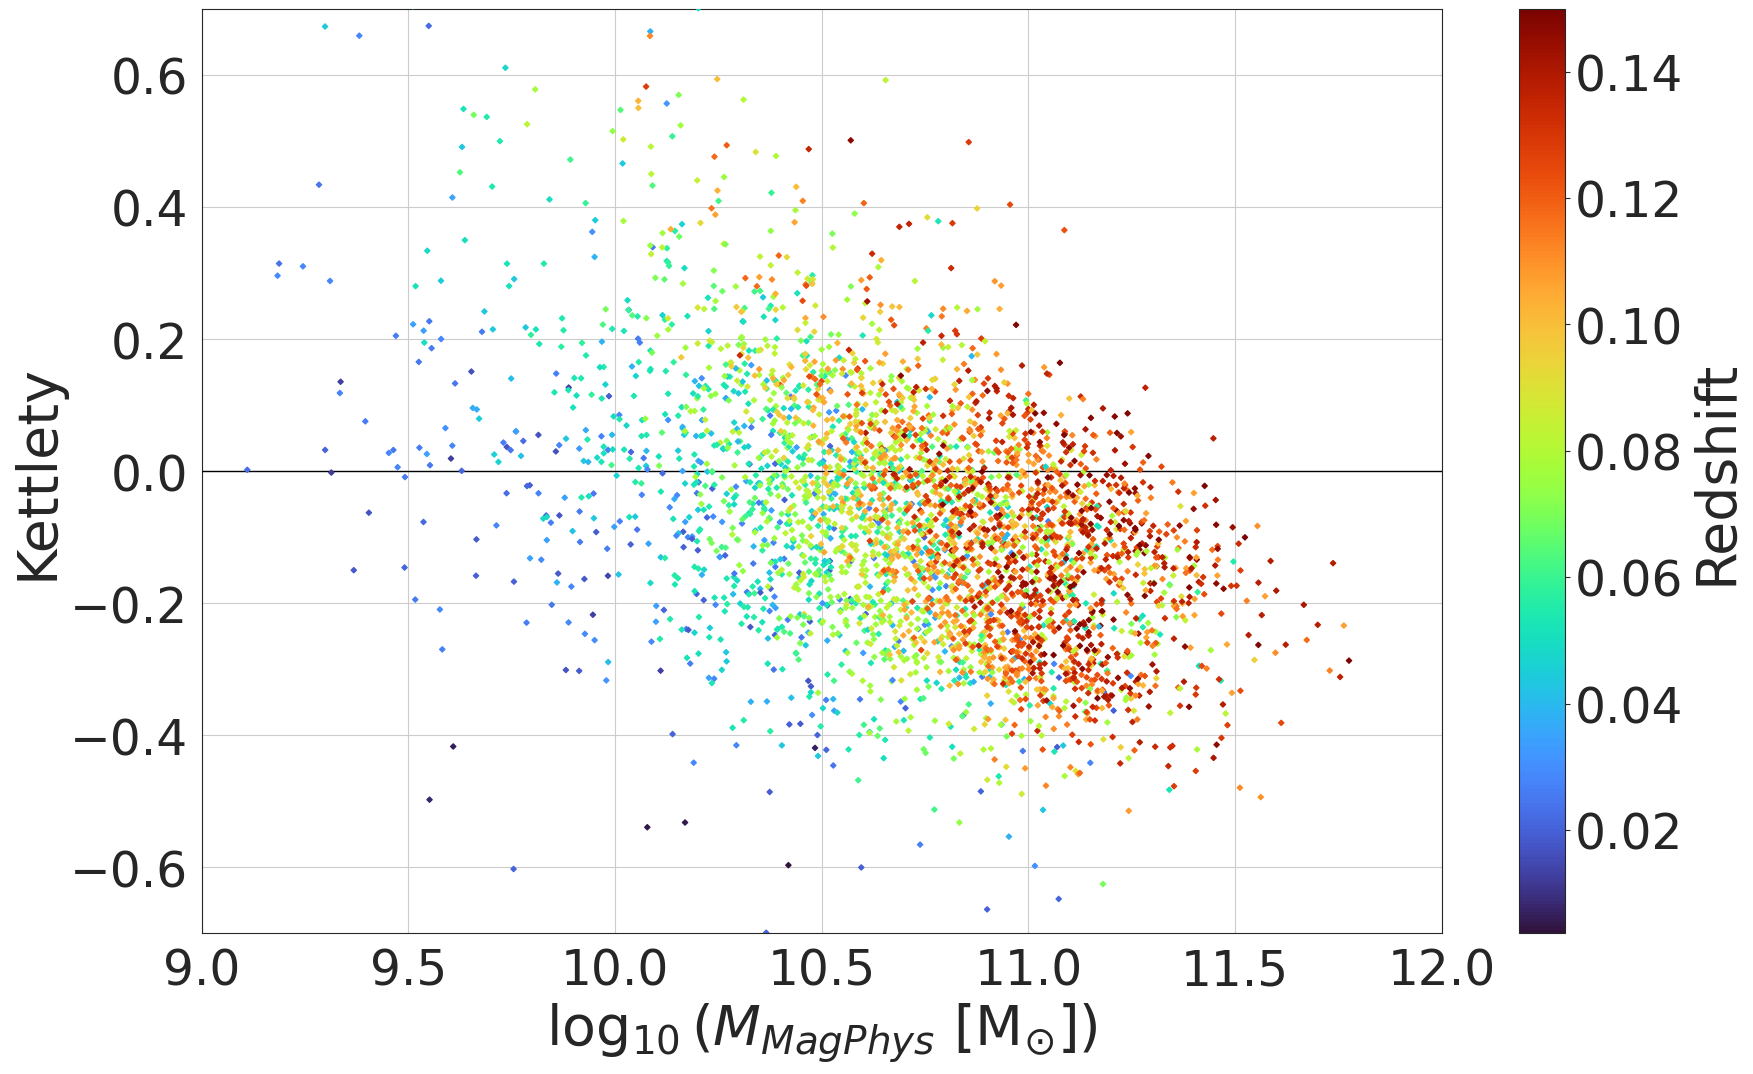

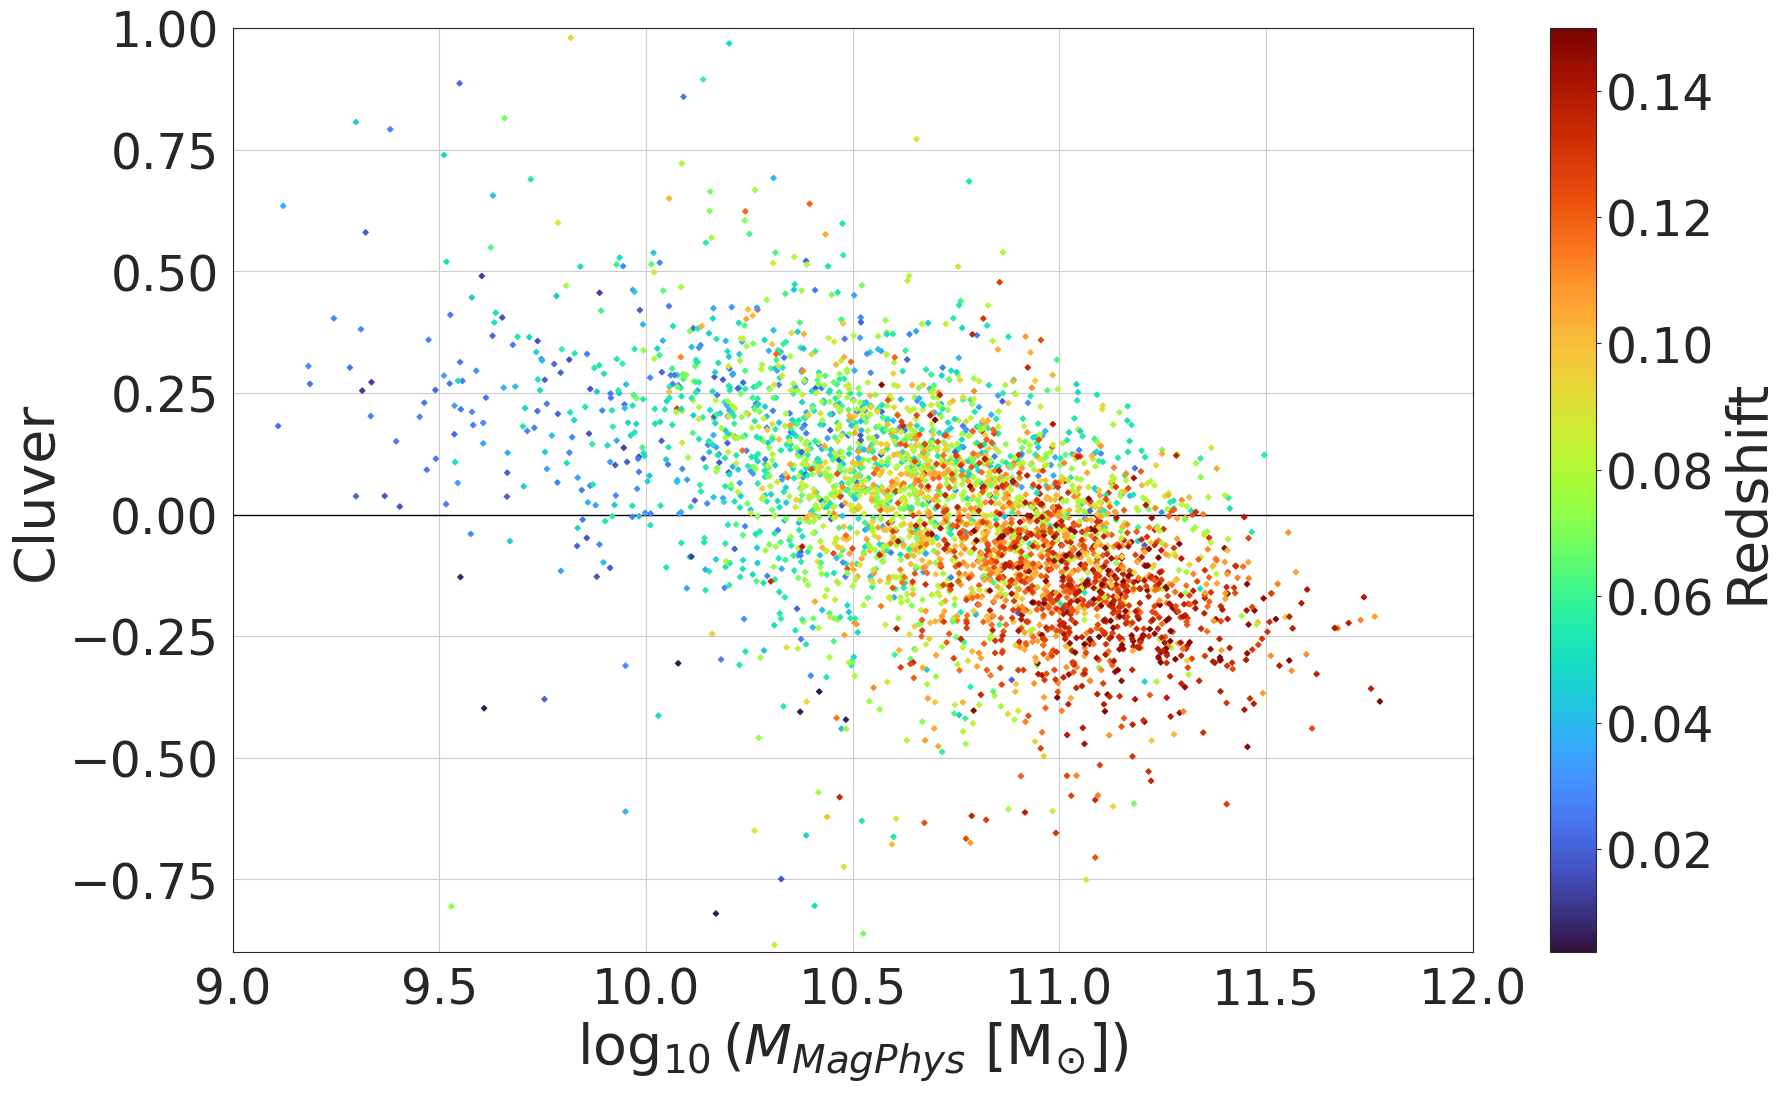

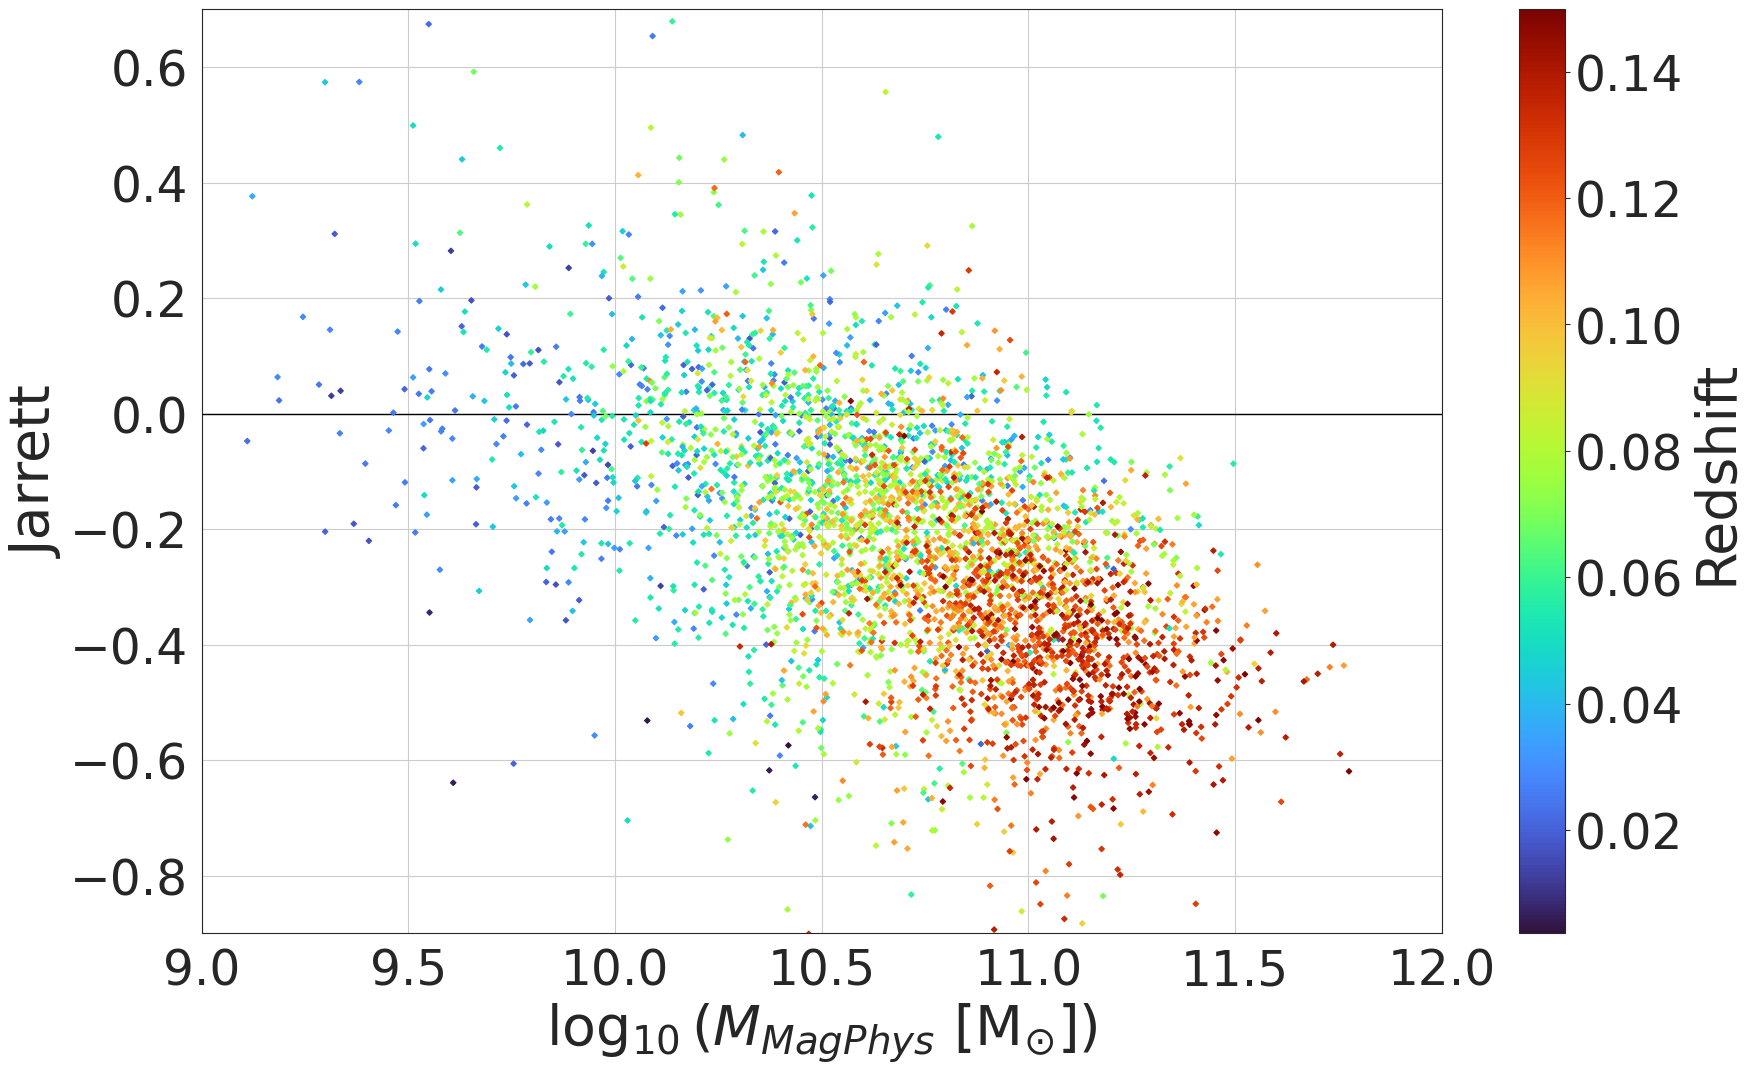

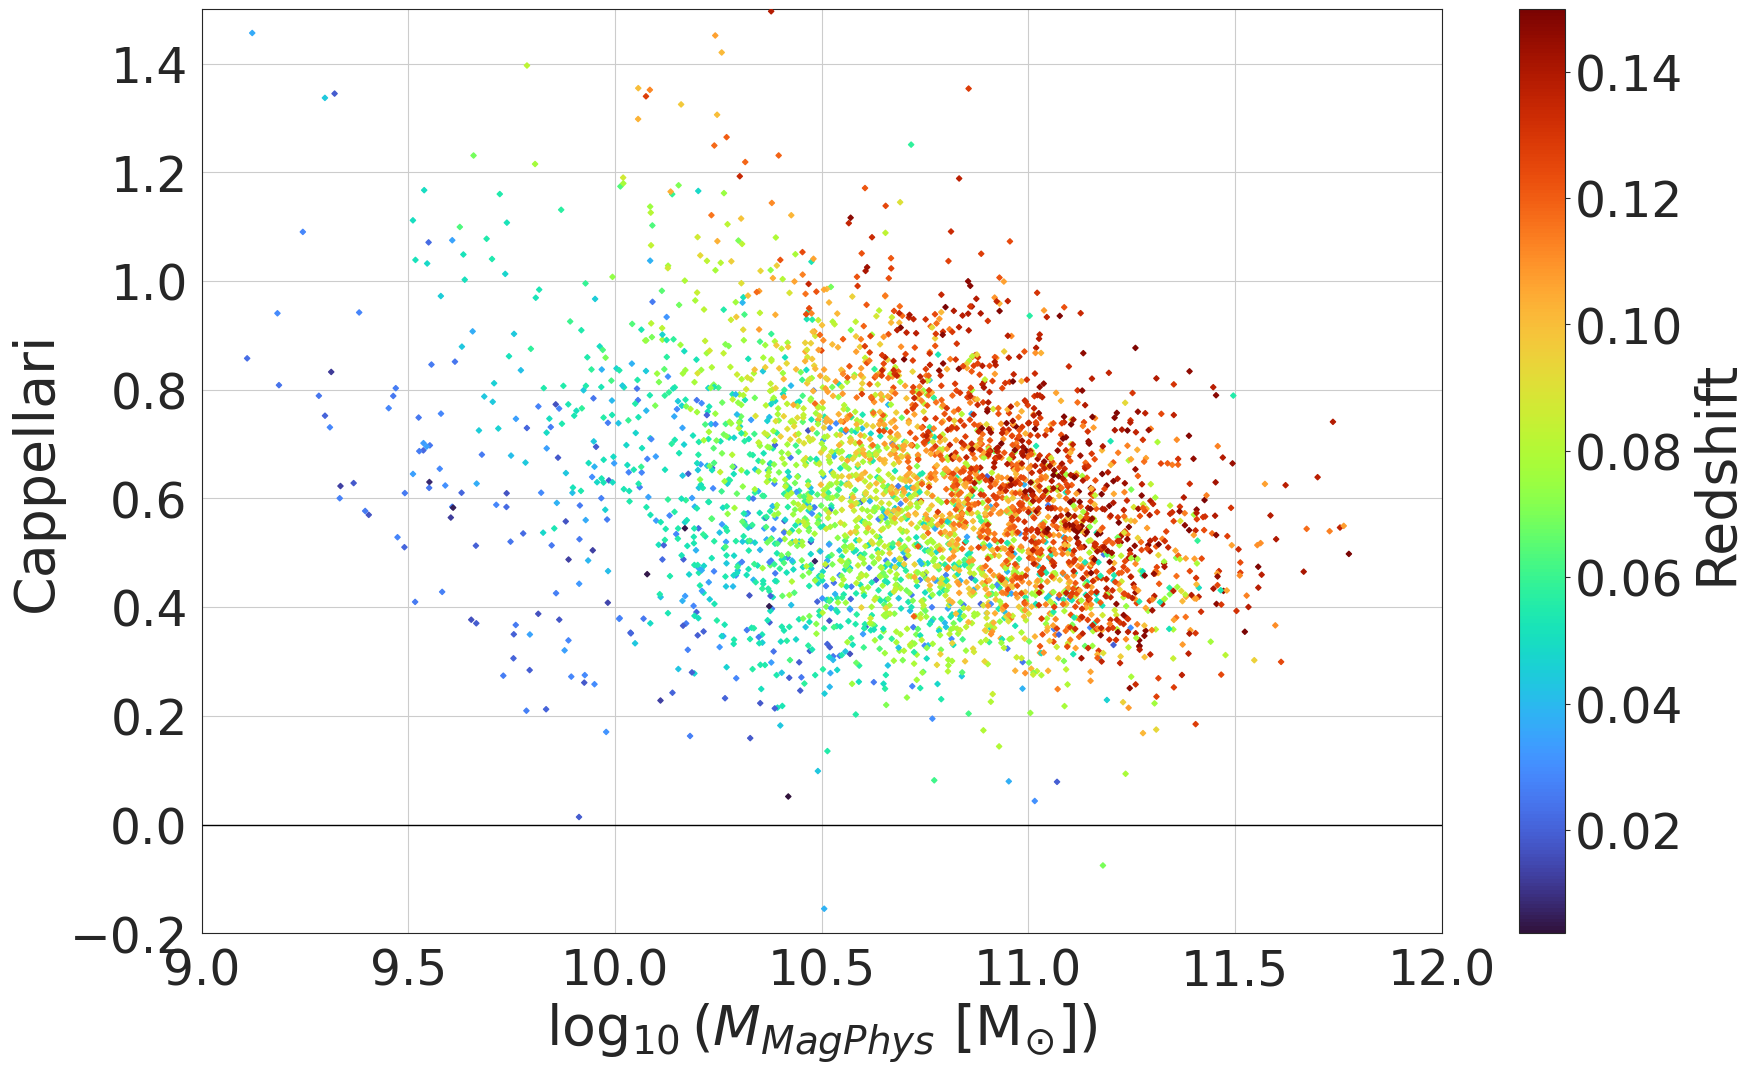

In [14]:
fraction_plot( check_lowz.SMass_Kettlety, check_lowz.log_gama_sm_magphys, 'Kettlety', '../new_plots_15/fraction_MagPhys_Kettlety.pdf',
               zarr=check_lowz.z, xmin = 9, xmax = 12, ymin = -0.7, ymax = 0.7, size = 7) 
fraction_plot( check_lowz.SMass_Cluver, check_lowz.log_gama_sm_magphys, 'Cluver', '../new_plots_15/fraction_MagPhys_Cluver.pdf',
               zarr=check_lowz.z, xmin = 9, xmax = 12, ymin = -0.9, ymax = 1, size = 7)
fraction_plot( check_lowz.SMass_Jarrett, check_lowz.log_gama_sm_magphys, 'Jarrett', '../new_plots_15/fraction_MagPhys_Jarrett.pdf',
               zarr=check_lowz.z, xmin = 9, xmax = 12, ymin = -0.9, ymax = 0.7 , size = 7)
fraction_plot( check_lowz.SMass_Cappellari, check_lowz.log_gama_sm_magphys, 'Cappellari', '../new_plots_15/fraction_MagPhys_Cappellari.pdf',
               zarr=check_lowz.z, xmin = 9, xmax = 12, ymin = -0.2, ymax = 1.5, size = 7)

Fraction plots for the stellar masses in GAMA:

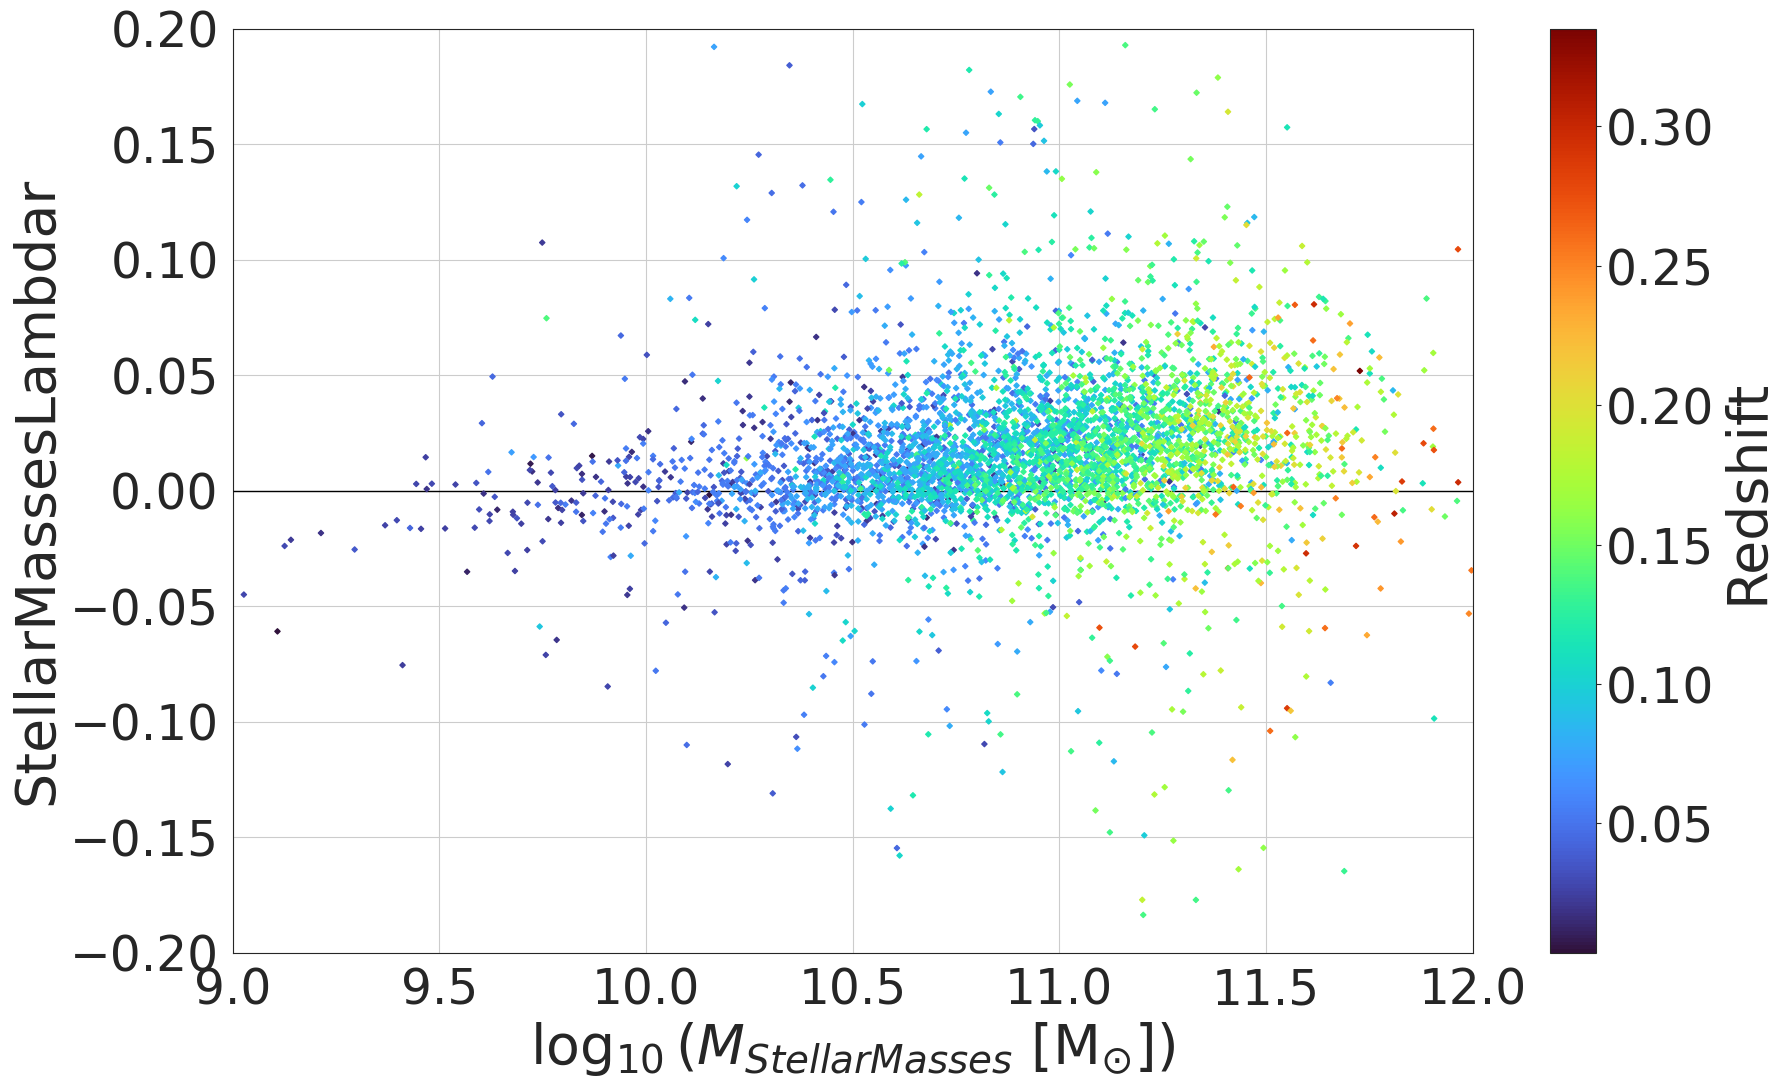

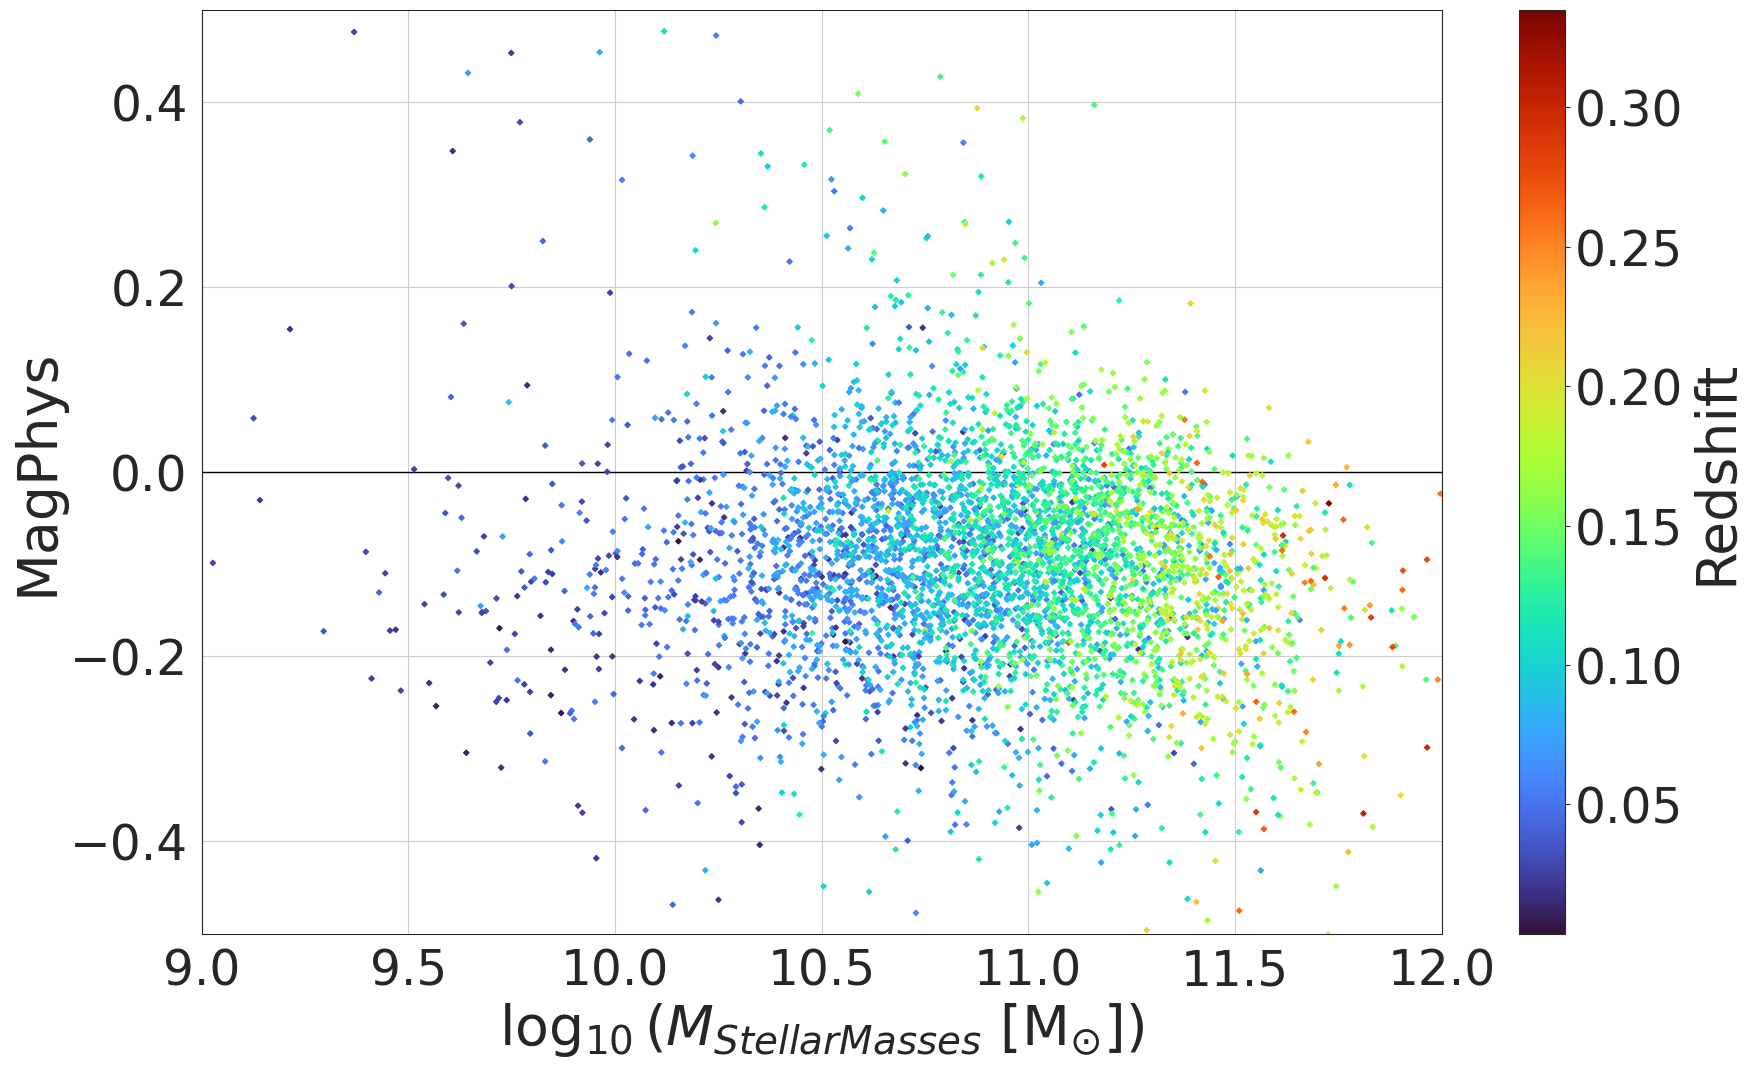

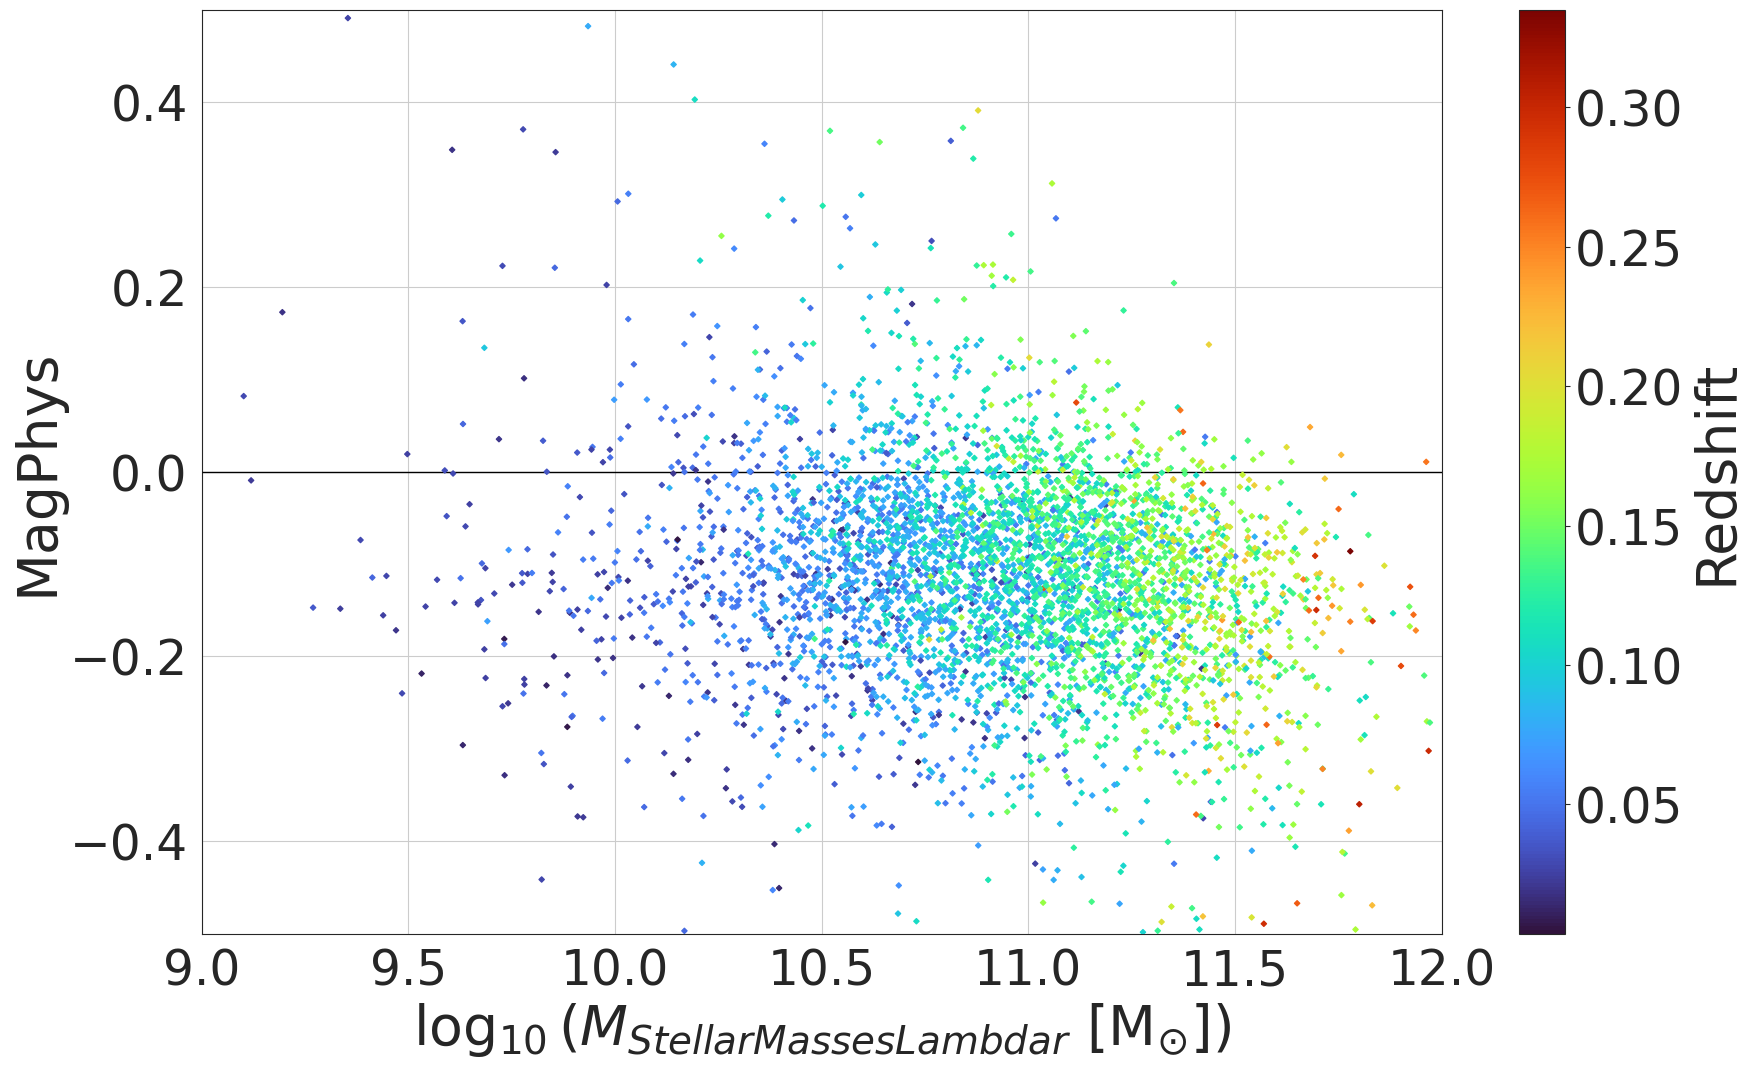

In [15]:
fraction_plot( check.log_gama_sm_lambdar, check.log_gama_sm, 'StellarMassesLambdar', '../new_plots/fraction_SM_Lambdar.pdf', 
               xname='$M_{StellarMasses}$', GAMA = True, xmin = 9, xmax = 12, ymin = -0.2, ymax = 0.2, size = 7) 
fraction_plot( check.log_gama_sm_magphys, check.log_gama_sm, 'MagPhys', '../new_plots/fraction_SM_Magphys.pdf',
               xname='$M_{StellarMasses}$', GAMA = True, xmin = 9, xmax = 12, ymin = -0.5, ymax = 0.5, size = 7)
fraction_plot( check.log_gama_sm_magphys, check.log_gama_sm_lambdar, 'MagPhys', '../new_plots/fraction_SMLambdar_Magphys.pdf',
               xname='$M_{StellarMassesLambdar}$', GAMA = True , xmin = 9, xmax = 12, ymin = -0.5, ymax = 0.5, size = 7)

#### Contour plots for comparison

In [16]:
# for the linear fitting
def linfit( x, a, b ):
    return a*x+b 

def MLE_fit( x, y, guess = np.array([1,2,2])):
    # MLE function
    # ml modeling and neg LL calculation
    def MLE_Norm(parameters):
        # extract parameters
        const, beta, std_dev = parameters
        # predict the output
        pred = const + beta*x
        # Calculate the log-likelihood for normal distribution
        LL = np.sum(stats.norm.logpdf(y, pred, std_dev))
        # Calculate the negative log-likelihood
        neg_LL = -1*LL
        return neg_LL 

    # minimize arguments: function, intial_guess_of_parameters, method
    return minimize(MLE_Norm, guess, method='Nelder-Mead' ) # 'L-BFGS-B', 'trust-constr'

https://stackoverflow.com/questions/33169093/how-to-label-a-seaborn-contour-plot

In [17]:
def compare_plot_contour( sample, gama, name, err, fname = None, xname = '$M_{MagPhys}$',  fsize = (20, 12), fs = 40, fst = 35, size = 2, guess = np.array([1,2,1]),
                          xmin = 8, xmax = 13 ):
    c = 1/(np.log(10)) # considering the errors, see Pearson_corr_sm.ipynb
    err = err*c
    sample = np.log10(sample)
    fig = plt.figure( figsize = (fsize), dpi = 100 )
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    pd.DataFrame( { "gama": gama, "sample" : sample } ).pyroplot.density( ax=ax, contours=[0.95, 0.68], linewidths=[2, 4], zorder = 10,
                                                                         colors = ['green', 'purple'], label_contours=False )
    plt.xlabel( '$\log_{10} ($' + xname +  ' [M$_{\odot}$])', fontsize = fs )
    plt.ylabel( '$\log_{10}($' + name + ' [M$_{\odot}$])', fontsize = fs )
    plt.xticks( fontsize = fst )
    plt.yticks( fontsize = fst )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)
    plt.rcParams["font.size"] = 30
    plt.xlim( xmin, xmax )
    plt.ylim( xmin, xmax )
    x = np.linspace( xmin, xmax, 100 )
    plt.plot(x, x, c = 'k', zorder = 10)
    plt.scatter( gama, sample, 3, 'black' )

    print('Least square method')
    plt.rcParams['agg.path.chunksize'] = 10000
    popt, pcov = curve_fit( linfit, gama, sample, sigma = err, absolute_sigma = True, p0 = [0.8, 2] )
    print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x + ', popt[1], '$\pm$', np.sqrt(pcov[1,1]) )
    
    print('Maximum likelihood method')
    mle_model = MLE_fit(gama, sample, guess)
    print(mle_model) 

    plt.rcParams["font.size"] = 32
    plt.grid()
    if fname != None:
        plt.plot( x, mle_model.x[1] * x + mle_model.x[0], lw = 1.5, ls = '-.',
             c = 'orange' )
        plt.plot( x, popt[0] * x + popt[1], lw = 1.5, ls = '-.',
             c = 'green' )
        plt.savefig( fname, format = 'pdf' )

    residuals = sample - linfit(sample, *popt)
    print( "RMSE: ",(np.sum(residuals**2)/(residuals.size-2))**0.5 )
    return popt;

**Plot with values from GAMA *StellarMasses* table**...

**...and values from Kettlety's method:**

In [18]:
Kettlety_SM = compare_plot_contour( check.SMass_Kettlety, check.log_gama_sm, '$M_{Kettlety}$', check.err_SMass_Kettlety, 
                                   '../new_plots_we/contour_SM_Kettlety.pdf', xname = '$M_{StellarMasses}$' )
plt.close()

Least square method
y = ( 0.8515008780301214 $\pm$ 0.0035177674138154352 )*x +  1.4844439464031538 $\pm$ 0.038914893474083695
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1446.7545980800478
             x: [ 2.104e+00  7.903e-01  1.734e-01]
           nit: 164
          nfev: 293
 final_simplex: (array([[ 2.104e+00,  7.903e-01,  1.734e-01],
                       [ 2.104e+00,  7.903e-01,  1.734e-01],
                       [ 2.104e+00,  7.903e-01,  1.734e-01],
                       [ 2.104e+00,  7.903e-01,  1.734e-01]]), array([-1.447e+03, -1.447e+03, -1.447e+03, -1.447e+03]))
RMSE:  0.12122928334810634


**...and values from Cluver's method:**

In [19]:
Cluver_SM = compare_plot_contour( check.SMass_Cluver, check.log_gama_sm, '$M_{Cluver}$', check.err_SMass_Cluver, 
                                 '../new_plots_we/contour_SM_Cluver.pdf', xname = '$M_{StellarMasses}$' )
plt.close()

Least square method
y = ( 0.7244536280207438 $\pm$ 0.0009552693028382551 )*x +  2.897538744748992 $\pm$ 0.010339881783175232
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1055.658588671542
             x: [ 3.215e+00  6.920e-01  1.897e-01]
           nit: 164
          nfev: 297
 final_simplex: (array([[ 3.215e+00,  6.920e-01,  1.897e-01],
                       [ 3.215e+00,  6.920e-01,  1.897e-01],
                       [ 3.215e+00,  6.920e-01,  1.897e-01],
                       [ 3.215e+00,  6.920e-01,  1.897e-01]]), array([-1.056e+03, -1.056e+03, -1.056e+03, -1.056e+03]))
RMSE:  0.11743460621626209


**...and values from Jarrett's method:**

In [20]:
Jarrett_SM = compare_plot_contour( check.SMass_Jarrett, check.log_gama_sm, '$M_{Jarrett}$', check.err_SMass_Jarrett,
                                  '../new_plots_we/contour_SM_Jarrett.pdf', xname = '$M_{StellarMasses}$' )
plt.close()

Least square method
y = ( 0.7023452405055842 $\pm$ 0.001986197738010487 )*x +  2.927078628739821 $\pm$ 0.021662883568536438
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -771.9149980827426
             x: [ 3.002e+00  6.899e-01  2.026e-01]
           nit: 180
          nfev: 316
 final_simplex: (array([[ 3.002e+00,  6.899e-01,  2.026e-01],
                       [ 3.002e+00,  6.899e-01,  2.026e-01],
                       [ 3.002e+00,  6.899e-01,  2.026e-01],
                       [ 3.002e+00,  6.899e-01,  2.026e-01]]), array([-7.719e+02, -7.719e+02, -7.719e+02, -7.719e+02]))
RMSE:  0.23110925414589267


**...and values from Cappellari's method:**

In [21]:
Cappellari_SM = compare_plot_contour( check.SMass_Cappellari, check.log_gama_sm, '$M_{Cappellari}$', check.err_SMass_Cappellari,
                                     '../new_plots_we/contour_SM_Cappellari.pdf', xname = '$M_{StellarMasses}$' )
plt.close()

Least square method
y = ( 0.903486654737005 $\pm$ 0.0024150711273891626 )*x +  1.5225425576130918 $\pm$ 0.026286320208078078
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -845.7349755006717
             x: [ 1.691e+00  8.922e-01  1.991e-01]
           nit: 143
          nfev: 252
 final_simplex: (array([[ 1.691e+00,  8.922e-01,  1.991e-01],
                       [ 1.690e+00,  8.922e-01,  1.991e-01],
                       [ 1.691e+00,  8.922e-01,  1.991e-01],
                       [ 1.691e+00,  8.922e-01,  1.991e-01]]), array([-8.457e+02, -8.457e+02, -8.457e+02, -8.457e+02]))
RMSE:  0.4227158153315905


**Plot with values from GAMA *StellarMassesLambdar* table**...

**...and values from Kettlety's method:**

In [22]:
Kettlety_Lambdar = compare_plot_contour( check.SMass_Kettlety, check.log_gama_sm_lambdar, '$M_{Kettlety}$', check.err_SMass_Kettlety,
                                        '../new_plots_we/contour_SMLambdar_Kettlety.pdf', xname = '$M_{StellarMassesLambdar}$' )
plt.close()

Least square method
y = ( 0.8389812047265043 $\pm$ 0.003479663610197167 )*x +  1.6027408235181226 $\pm$ 0.038577279377549796
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1423.572843075035
             x: [ 2.229e+00  7.776e-01  1.743e-01]
           nit: 162
          nfev: 300
 final_simplex: (array([[ 2.229e+00,  7.776e-01,  1.743e-01],
                       [ 2.229e+00,  7.776e-01,  1.743e-01],
                       [ 2.229e+00,  7.776e-01,  1.743e-01],
                       [ 2.229e+00,  7.776e-01,  1.743e-01]]), array([-1.424e+03, -1.424e+03, -1.424e+03, -1.424e+03]))
RMSE:  0.13756372266208114


**...and values from Cluver's method:**

In [23]:
Cluver_Lambdar = compare_plot_contour( check.SMass_Cluver, check.log_gama_sm_lambdar, '$M_{Cluver}$', check.err_SMass_Cluver,
                                      '../new_plots_we/contour_SMLambdar_Cluver.pdf', xname = '$M_{StellarMassesLambdar}$' )
plt.close()

Least square method
y = ( 0.7141369323480411 $\pm$ 0.00094208105436776 )*x +  2.9984834871927606 $\pm$ 0.010211404830113024
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1050.987144723585
             x: [ 3.317e+00  6.815e-01  1.900e-01]
           nit: 164
          nfev: 295
 final_simplex: (array([[ 3.317e+00,  6.815e-01,  1.900e-01],
                       [ 3.317e+00,  6.815e-01,  1.900e-01],
                       [ 3.317e+00,  6.815e-01,  1.899e-01],
                       [ 3.317e+00,  6.815e-01,  1.900e-01]]), array([-1.051e+03, -1.051e+03, -1.051e+03, -1.051e+03]))
RMSE:  0.12629280463108708


**...and values from Jarrett's method:**

In [24]:
Jarrett_Lambdar = compare_plot_contour( check.SMass_Jarrett, check.log_gama_sm_lambdar, '$M_{Jarrett}$', check.err_SMass_Jarrett,
                                       '../new_plots_we/contour_SMLambdar_Jarrett.pdf', xname = '$M_{StellarMassesLambdar}$' )
plt.close()

Least square method
y = ( 0.6910642299133612 $\pm$ 0.001955255139041133 )*x +  3.0376775126326505 $\pm$ 0.021360834628506145
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -770.5730324589491
             x: [ 3.101e+00  6.797e-01  2.026e-01]
           nit: 169
          nfev: 310
 final_simplex: (array([[ 3.101e+00,  6.797e-01,  2.026e-01],
                       [ 3.101e+00,  6.797e-01,  2.026e-01],
                       [ 3.101e+00,  6.797e-01,  2.026e-01],
                       [ 3.101e+00,  6.797e-01,  2.026e-01]]), array([-7.706e+02, -7.706e+02, -7.706e+02, -7.706e+02]))
RMSE:  0.2401672148723146


**...and values from Cappellari's method:**

In [25]:
Cappellari_Lambdar = compare_plot_contour( check.SMass_Cappellari, check.log_gama_sm_lambdar, '$M_{Cappellari}$', check.err_SMass_Cappellari,
                                          '../new_plots_we/contour_SMLambdar_Cappellari.pdf', xname = '$M_{StellarMassesLambdar}$' )
plt.close()

Least square method
y = ( 0.8933221063333466 $\pm$ 0.0023958535929392384 )*x +  1.6181865540064158 $\pm$ 0.02611741778822091
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -759.7776575623675
             x: [ 1.871e+00  8.742e-01  2.031e-01]
           nit: 154
          nfev: 283
 final_simplex: (array([[ 1.871e+00,  8.742e-01,  2.031e-01],
                       [ 1.871e+00,  8.742e-01,  2.031e-01],
                       [ 1.871e+00,  8.742e-01,  2.031e-01],
                       [ 1.871e+00,  8.742e-01,  2.031e-01]]), array([-7.598e+02, -7.598e+02, -7.598e+02, -7.598e+02]))
RMSE:  0.40287330365245727


**Plot with values from GAMA *StellarMasses* table**...

**...and values from Kettlety's method:**

In [26]:
Kettlety_Magphys = compare_plot_contour( check.SMass_Kettlety, check.log_gama_sm_magphys, '$M_{Kettlety}$', check.err_SMass_Kettlety,
                                        '../new_plots_we/contour_MagPhys_Kettlety.pdf' )
plt.close()

Least square method
y = ( 0.839354063905759 $\pm$ 0.0034756680589285546 )*x +  1.71777247858366 $\pm$ 0.038039940039747776
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1493.917408559721
             x: [ 2.109e+00  7.973e-01  1.715e-01]
           nit: 155
          nfev: 282
 final_simplex: (array([[ 2.109e+00,  7.973e-01,  1.715e-01],
                       [ 2.109e+00,  7.974e-01,  1.715e-01],
                       [ 2.109e+00,  7.974e-01,  1.715e-01],
                       [ 2.109e+00,  7.973e-01,  1.715e-01]]), array([-1.494e+03, -1.494e+03, -1.494e+03, -1.494e+03]))
RMSE:  0.0608377273487902


**...and values from Cluver's method:**

In [27]:
Cluver_Magphys = compare_plot_contour( check.SMass_Cluver, check.log_gama_sm_magphys, '$M_{Cluver}$', check.err_SMass_Cluver,
                                      '../new_plots_we/contour_MagPhys_Cluver.pdf' )
plt.close()

Least square method
y = ( 0.7127962989040171 $\pm$ 0.000951448514457561 )*x +  3.1038106660336373 $\pm$ 0.010191640713272778
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -874.7216262743765
             x: [ 3.379e+00  6.834e-01  1.978e-01]
           nit: 161
          nfev: 291
 final_simplex: (array([[ 3.379e+00,  6.834e-01,  1.978e-01],
                       [ 3.379e+00,  6.834e-01,  1.978e-01],
                       [ 3.378e+00,  6.834e-01,  1.978e-01],
                       [ 3.379e+00,  6.834e-01,  1.978e-01]]), array([-8.747e+02, -8.747e+02, -8.747e+02, -8.747e+02]))
RMSE:  0.10140184449658778


**...and values from Jarrett's method:**

In [28]:
Jarrett_Magphys = compare_plot_contour( check.SMass_Jarrett, check.log_gama_sm_magphys, '$M_{Jarrett}$', check.err_SMass_Jarrett,
                                       '../new_plots_we/contour_MagPhys_Jarrett.pdf' )
plt.close()

Least square method
y = ( 0.6924144366669002 $\pm$ 0.001977316635437361 )*x +  3.1126581547432206 $\pm$ 0.02134545747445098
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -594.4627035245437
             x: [ 3.182e+00  6.798e-01  2.110e-01]
           nit: 163
          nfev: 296
 final_simplex: (array([[ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01]]), array([-5.945e+02, -5.945e+02, -5.945e+02, -5.945e+02]))
RMSE:  0.16566484171062712


**...and values from Cappellari's method:**

In [29]:
Cappellari_Magphys = compare_plot_contour( check.SMass_Cappellari, check.log_gama_sm_magphys, '$M_{Cappellari}$', check.err_SMass_Cappellari,
                                          '../new_plots_we/contour_MagPhys_Cappellari.pdf' )
plt.close()

Least square method
y = ( 0.9234691024550803 $\pm$ 0.002434216144268738 )*x +  1.4060935181717367 $\pm$ 0.026228670125573908
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -915.2811814155997
             x: [ 1.682e+00  9.015e-01  1.960e-01]
           nit: 129
          nfev: 235
 final_simplex: (array([[ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01]]), array([-9.153e+02, -9.153e+02, -9.153e+02, -9.153e+02]))
RMSE:  0.5334266932374485


#### Plots with all fitted linears

**for Kettlety's method:**

Least square method
y = ( 0.839354063905759 $\pm$ 0.0034756680589285546 )*x +  1.71777247858366 $\pm$ 0.038039940039747776
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1493.917408559721
             x: [ 2.109e+00  7.973e-01  1.715e-01]
           nit: 155
          nfev: 282
 final_simplex: (array([[ 2.109e+00,  7.973e-01,  1.715e-01],
                       [ 2.109e+00,  7.974e-01,  1.715e-01],
                       [ 2.109e+00,  7.974e-01,  1.715e-01],
                       [ 2.109e+00,  7.973e-01,  1.715e-01]]), array([-1.494e+03, -1.494e+03, -1.494e+03, -1.494e+03]))
RMSE:  0.0608377273487902


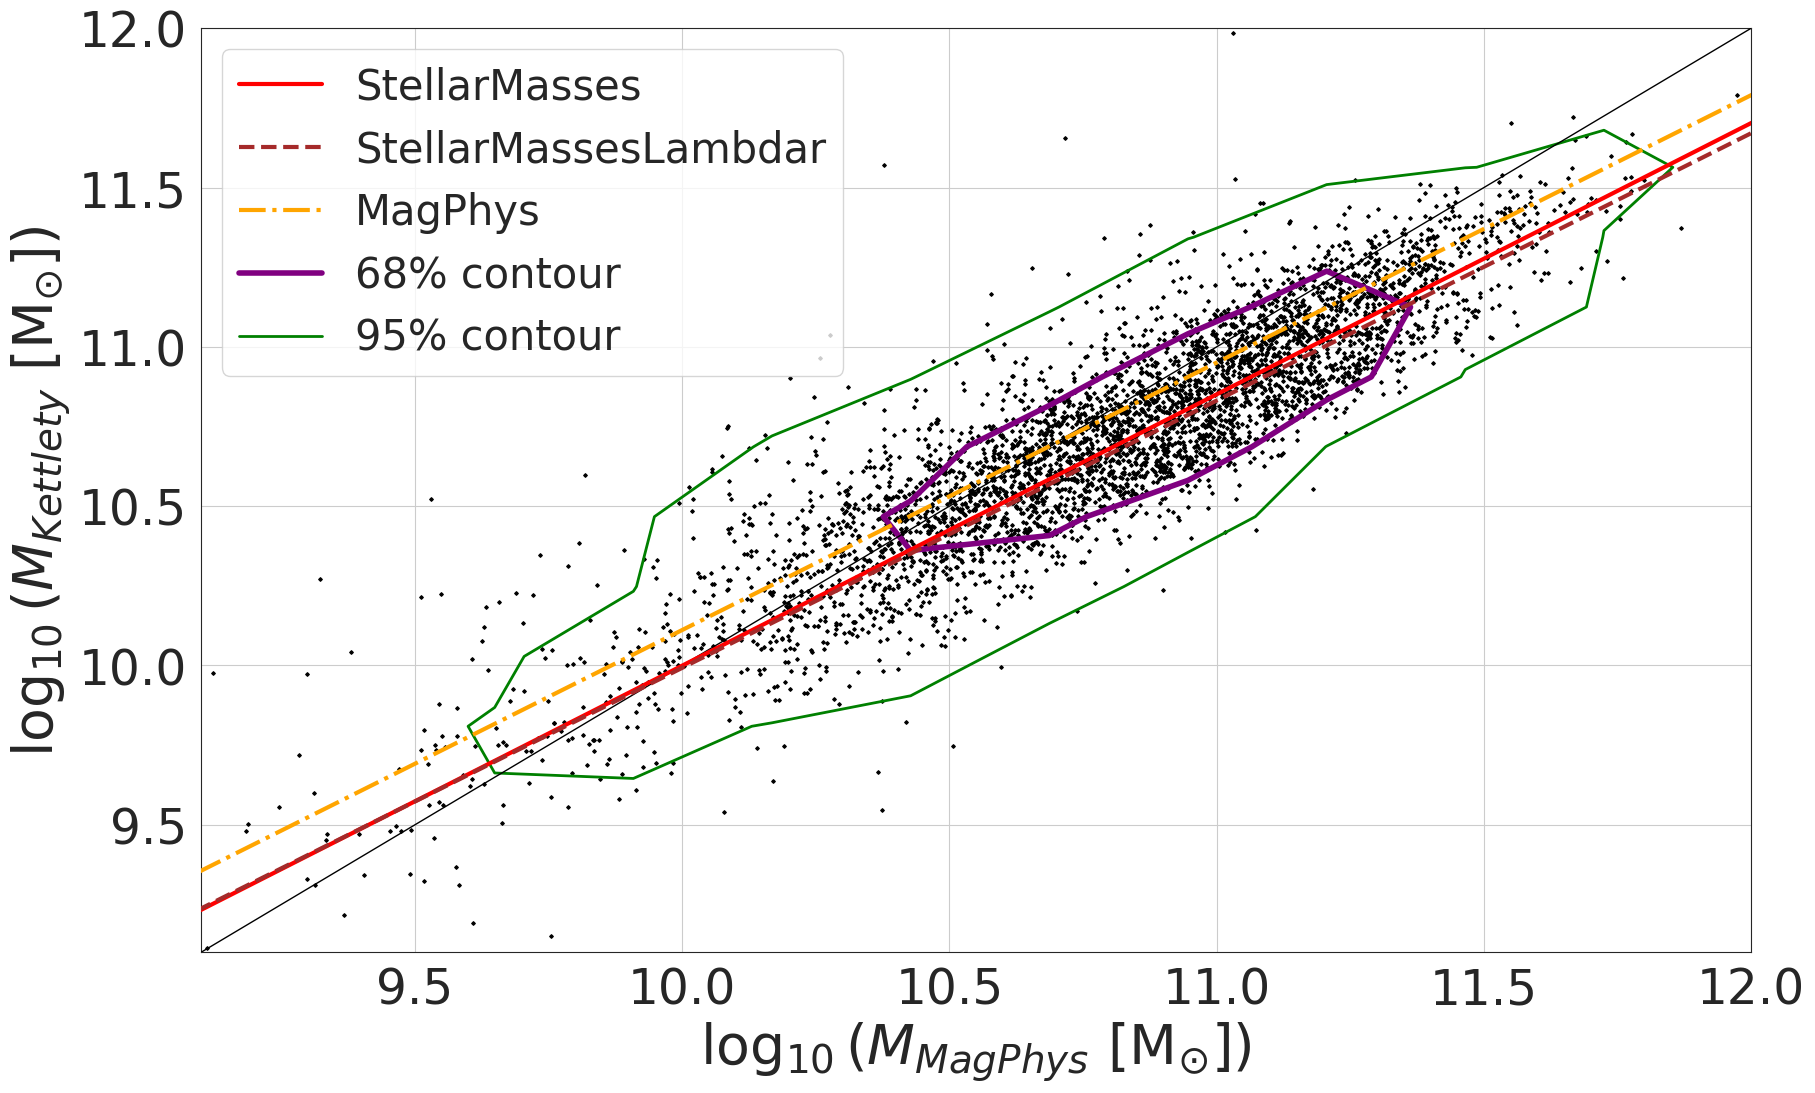

In [30]:
compare_plot_contour( check.SMass_Kettlety, check.log_gama_sm_magphys, '$M_{Kettlety}$', check.err_SMass_Kettlety,  xmin = 9.1, xmax = 12 )
x = np.linspace( 8, 13, 100 )
plt.plot( x, Kettlety_SM[0] * x + Kettlety_SM[1], lw = 3, ls = '-', c = 'red', zorder = 50 )
plt.plot( x, Kettlety_Lambdar[0] * x + Kettlety_Lambdar[1], lw = 3, ls = '--', c = 'brown', zorder = 50 )
plt.plot( x, Kettlety_Magphys[0] * x + Kettlety_Magphys[1], lw = 3, ls = '-.', c = 'orange', zorder = 50)
custom_lines = [Line2D([0], [0], color='red', lw=3, label = 'StellarMasses'),
                Line2D([0], [0], color='brown', lw=3, ls = '--', label = 'StellarMassesLambdar'),
                Line2D([0], [0], color='orange', lw=3, ls = '-.', label = 'MagPhys'),
                Line2D([0], [0], color='purple', lw=4, label = '68% contour'),
                Line2D([0], [0], color='green', lw=2,  label = '95% contour') ]
plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0, 1), fontsize = 30, handles = custom_lines )
plt.savefig( '../new_plots_we/all_fits_Kettlety.pdf', format = 'pdf' );

**for Cluver's method:**

Least square method
y = ( 0.7127962989040171 $\pm$ 0.000951448514457561 )*x +  3.1038106660336373 $\pm$ 0.010191640713272778
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -874.7216262743765
             x: [ 3.379e+00  6.834e-01  1.978e-01]
           nit: 161
          nfev: 291
 final_simplex: (array([[ 3.379e+00,  6.834e-01,  1.978e-01],
                       [ 3.379e+00,  6.834e-01,  1.978e-01],
                       [ 3.378e+00,  6.834e-01,  1.978e-01],
                       [ 3.379e+00,  6.834e-01,  1.978e-01]]), array([-8.747e+02, -8.747e+02, -8.747e+02, -8.747e+02]))
RMSE:  0.10140184449658778


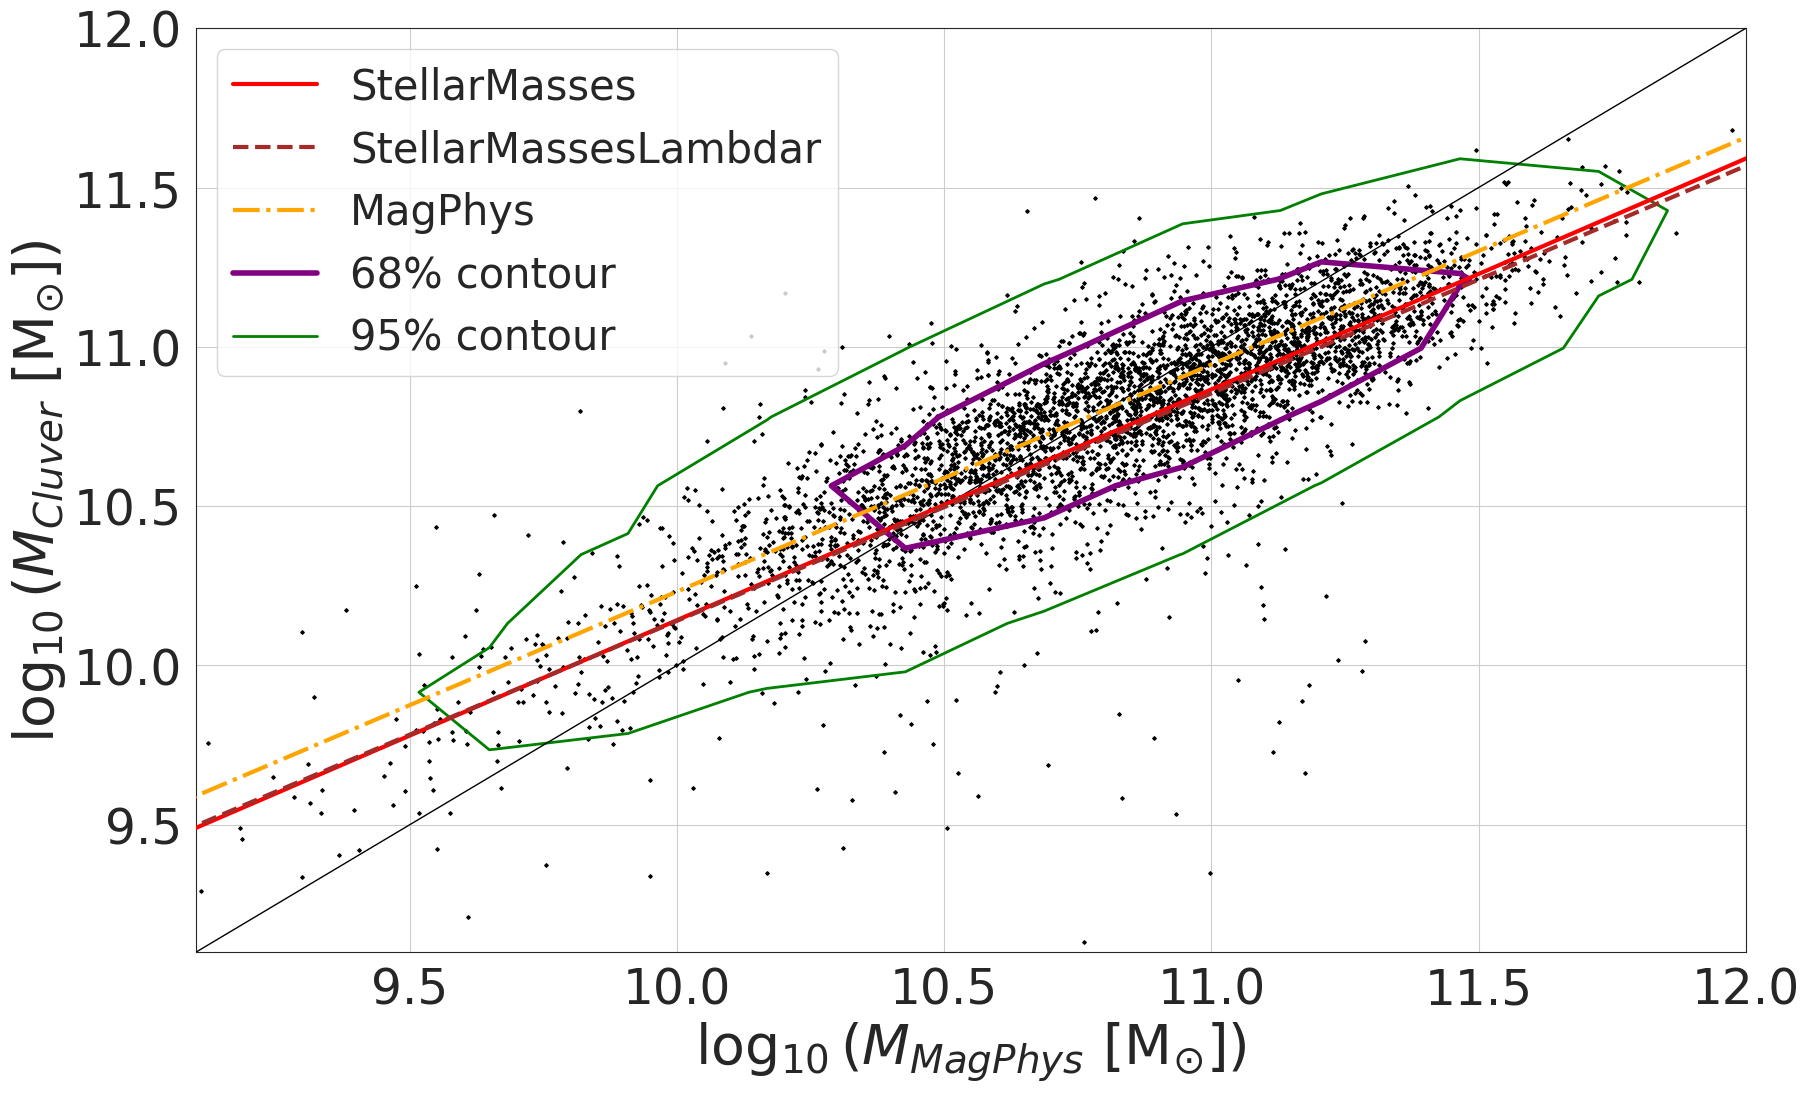

In [31]:
compare_plot_contour( check.SMass_Cluver, check.log_gama_sm_magphys, '$M_{Cluver}$', check.err_SMass_Cluver, xmin = 9.1, xmax = 12 )
x = np.linspace( 8, 13, 100 )
plt.plot( x, Cluver_SM[0] * x + Cluver_SM[1], lw = 3, ls = '-',
         c = 'red', label = 'StellarMasses', zorder = 50 )
plt.plot( x, Cluver_Lambdar[0] * x + Cluver_Lambdar[1], lw = 3, ls = '--',
         c = 'brown', label = 'StellarMassesLambdar', zorder = 50)
plt.plot( x, Cluver_Magphys[0] * x + Cluver_Magphys[1], lw = 3, ls = '-.',
         c = 'orange', label = 'MagPhys', zorder = 50 )
plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0, 1), fontsize = 30, handles = custom_lines )
plt.savefig( '../new_plots_we/all_fits_Cluver.pdf', format = 'pdf' );

**for Jarrett's method:**

Least square method
y = ( 0.6924144366669002 $\pm$ 0.001977316635437361 )*x +  3.1126581547432206 $\pm$ 0.02134545747445098
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -594.4627035245437
             x: [ 3.182e+00  6.798e-01  2.110e-01]
           nit: 163
          nfev: 296
 final_simplex: (array([[ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01],
                       [ 3.182e+00,  6.798e-01,  2.110e-01]]), array([-5.945e+02, -5.945e+02, -5.945e+02, -5.945e+02]))
RMSE:  0.16566484171062712


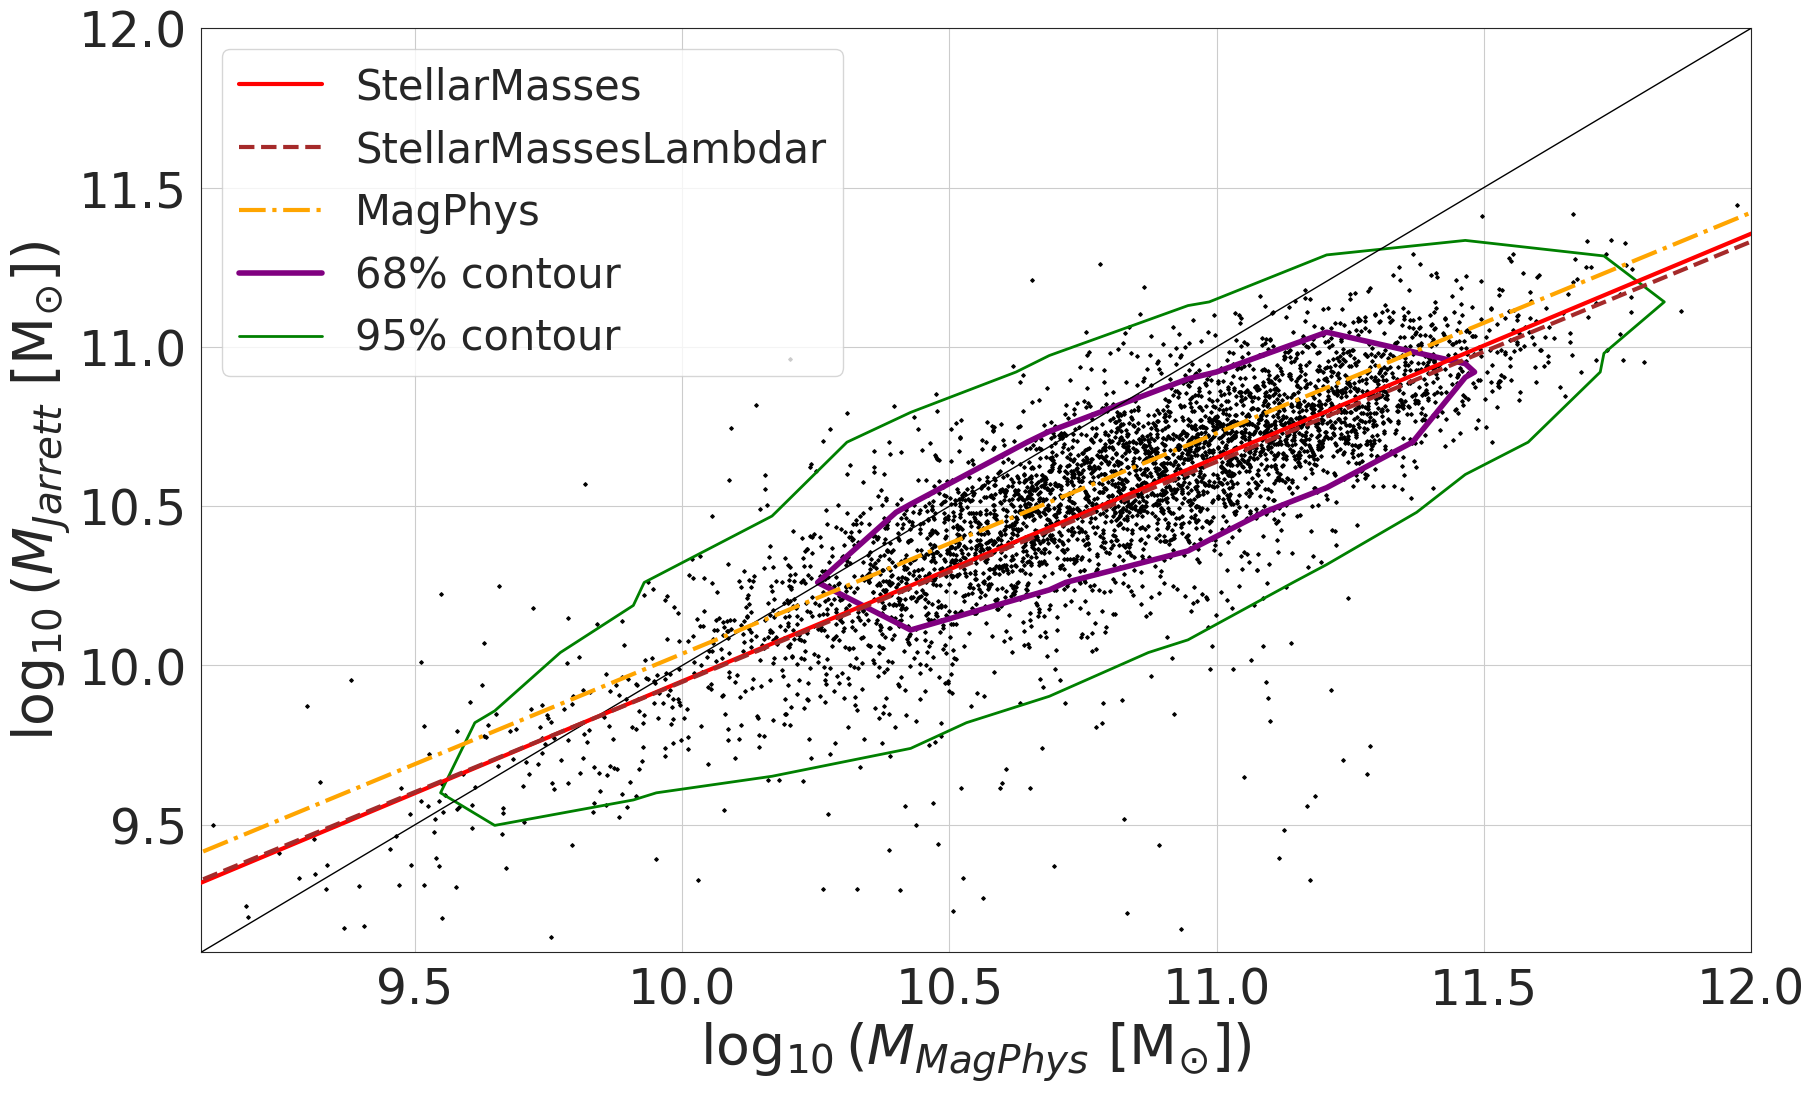

In [32]:
compare_plot_contour( check.SMass_Jarrett, check.log_gama_sm_magphys, '$M_{Jarrett}$', check.err_SMass_Jarrett, xmin = 9.1, xmax = 12 )
x = np.linspace( 8, 13, 100 )
plt.plot( x, Jarrett_SM[0] * x + Jarrett_SM[1], lw = 3, ls = '-',
         c = 'red', label = 'StellarMasses', zorder = 50)
plt.plot( x, Jarrett_Lambdar[0] * x + Jarrett_Lambdar[1], lw = 3, ls = '--',
         c = 'brown', label = 'StellarMassesLambdar', zorder = 50)
plt.plot( x, Jarrett_Magphys[0] * x + Jarrett_Magphys[1], lw = 3, ls = '-.',
         c = 'orange', label = 'MagPhys', zorder = 50 )
plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0, 1), fontsize = 30, handles = custom_lines )
plt.savefig( '../new_plots_we/all_fits_Jarrett.pdf', format = 'pdf' );

**for Cappellari's method:**

Least square method
y = ( 0.9440819786574117 $\pm$ 0.0019773166249652885 )*x +  1.1853333689948777 $\pm$ 0.021345457296949463
Maximum likelihood method
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -915.2811814155997
             x: [ 1.682e+00  9.015e-01  1.960e-01]
           nit: 129
          nfev: 235
 final_simplex: (array([[ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01],
                       [ 1.682e+00,  9.015e-01,  1.960e-01]]), array([-9.153e+02, -9.153e+02, -9.153e+02, -9.153e+02]))
RMSE:  0.5475353058173607


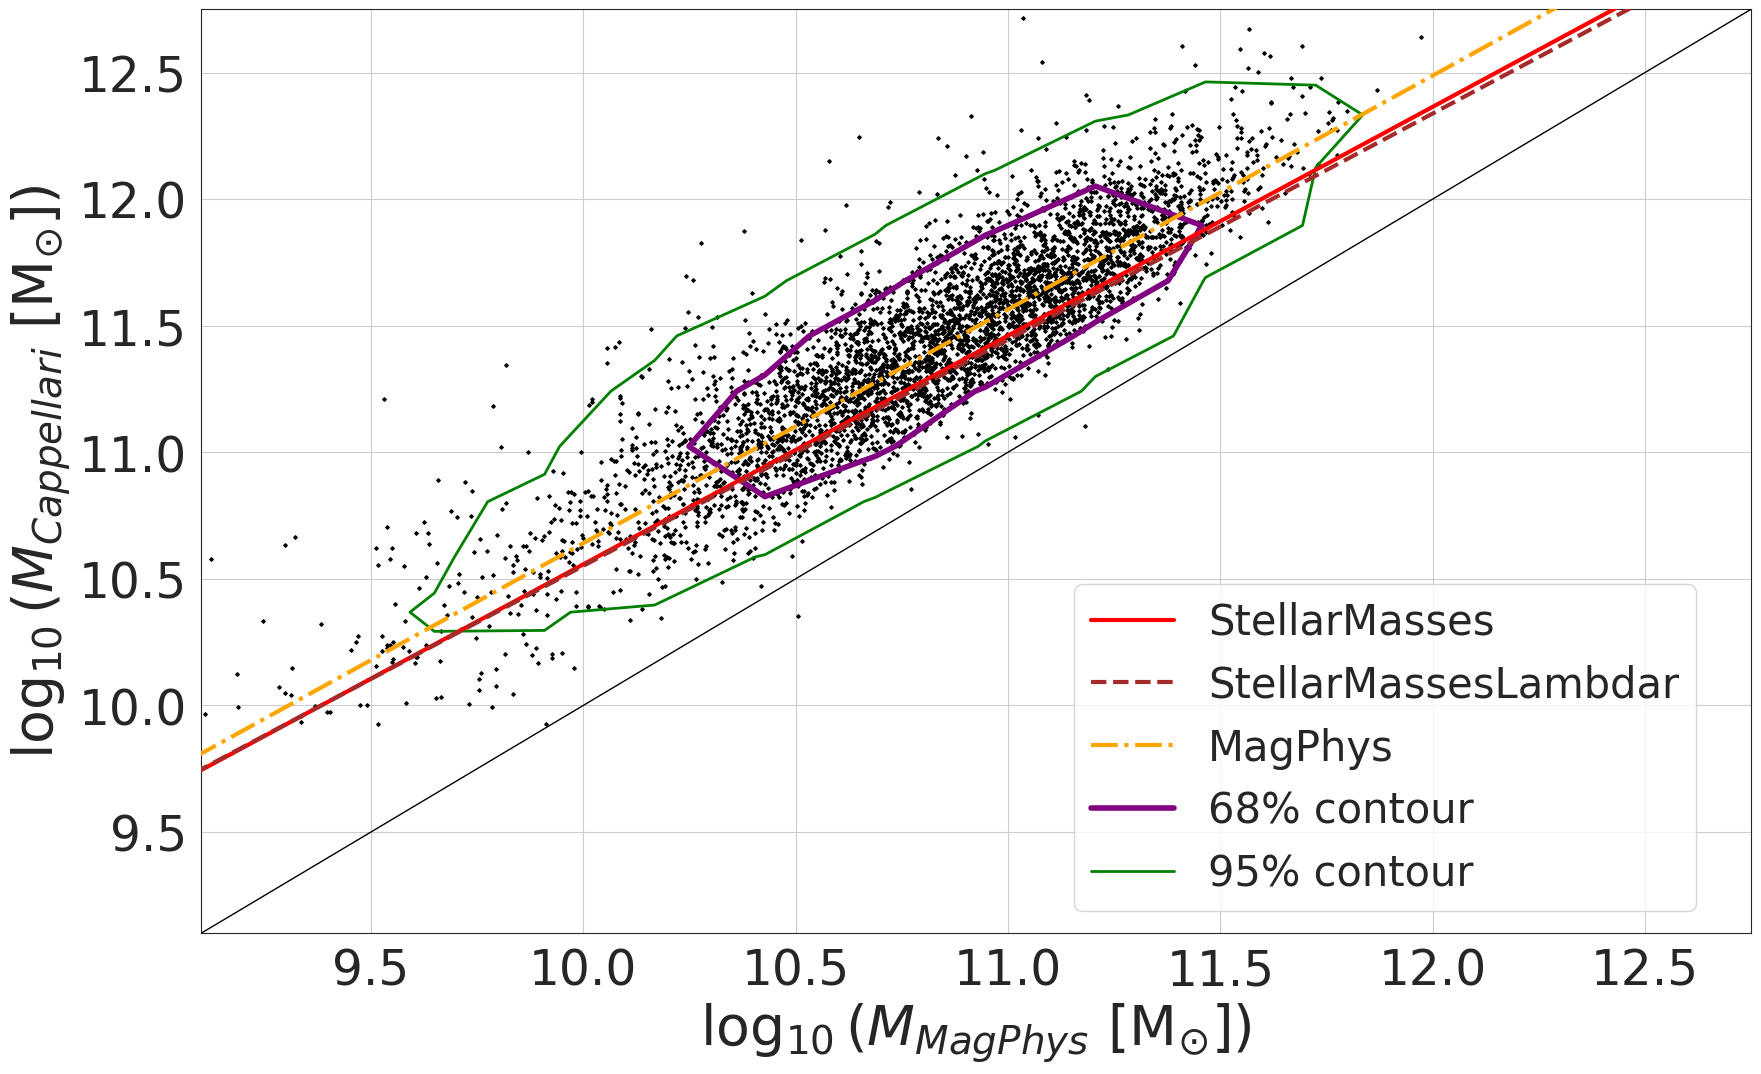

In [33]:
compare_plot_contour( check.SMass_Cappellari, check.log_gama_sm_magphys, '$M_{Cappellari}$', check.err_SMass_Jarrett, 
                     xmin = 9.1, xmax = 12.75 )
x = np.linspace( 8, 13, 100 )
plt.plot( x, Cappellari_SM[0] * x + Cappellari_SM[1], lw = 3, ls = '-',
         c = 'red', label = 'StellarMasses', zorder = 50)
plt.plot( x, Cappellari_Lambdar[0] * x + Cappellari_Lambdar[1], lw = 3, ls = '--',
         c = 'brown', label = 'StellarMassesLambdar', zorder = 50)
plt.plot( x, Cappellari_Magphys[0] * x + Cappellari_Magphys[1], lw = 3, ls = '-.',
         c = 'orange', label = 'MagPhys', zorder = 50)
plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0.55, 0.4), fontsize = 30, handles = custom_lines )
plt.savefig( '../new_plots_we/all_fits_Cappellari.pdf' , format = 'pdf' );